# Robust Brain MRI Classification on Latent Representations Leveraging Denoising Diffusion Probabilistic Models


In [1]:
from utils import *
from models import *

## Dataset Preparation and Splitting

In [ ]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Path to the data folder
data_dir = "/binary_one_type_split"

# Standard image size
image_size = 256

# Transformations to apply: resize, tensor conversion, and normalization
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),  # converts to [0,1]
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # normalization for 3 channels
])

# Original dataset for training
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform)

# Split into train and validation (80% - 20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Generator with seed for reproducibility
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)

# Dataset for testing
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64)

# Print dataset sizes
print(f"Train samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")

# Split test data into 60% and 40% for calibration and testing respectively
test_size = len(test_dataset)
calibration_size = int(0.45 * test_size)
remaining_size = test_size - calibration_size
calibration_subset, test_subset = random_split(test_dataset, [calibration_size, remaining_size], generator=generator)

# DataLoaders for calibration and test sets
calibration_loader = DataLoader(calibration_subset, batch_size=64)
test_loader = DataLoader(test_subset, batch_size=64)

print(f"Calibration samples: {len(calibration_subset)}")
print(f"Test samples: {len(test_subset)}")


Train samples: 2416
Validation samples: 604
Calibration samples: 339
Test samples: 416


Check class balance across subsets

In [3]:
# Get targets for each subset
train_targets = get_targets_from_subset(train_subset)
val_targets = get_targets_from_subset(val_subset)
test_targets = get_targets_from_subset(test_subset)
calibration_targets = get_targets_from_subset(calibration_subset)

print("Class distribution in subsets:")
print("Train:", Counter(train_targets))
print("Validation:", Counter(val_targets))
print("Test:", Counter(test_targets))
print("Calibration:", Counter(calibration_targets))


Class distribution in subsets:
Train: Counter({1: 1260, 0: 1156})
Validation: Counter({1: 340, 0: 264})
Test: Counter({1: 223, 0: 193})
Calibration: Counter({1: 177, 0: 162})


No, the subsets are not significantly imbalanced. The class distributions are fairly balanced and consistent across all splits.

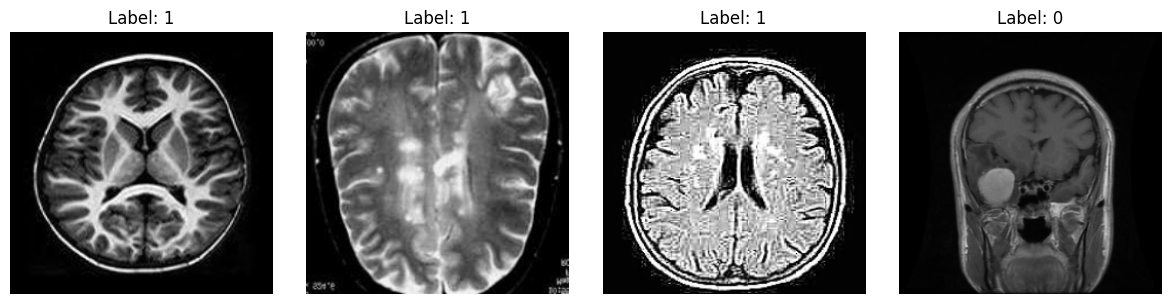

In [43]:
import matplotlib.pyplot as plt

# Visualize some images from the training set
images, labels = next(iter(train_loader))

# Normalize images to [0, 1] for visualization
images = images * 0.5 + 0.5

# Plot the first 4 images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = images[i].permute(1, 2, 0).squeeze()  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## Autoencoder, implementation and training

In [ ]:
# Initialize the model, loss function, and optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(latent_dim=128).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
num_epochs = 200  
patience = 10       # number of epochs without improvement before triggering early stopping
min_delta = 0.001   # minimum improvement threshold
best_loss = float('inf')
trigger_times = 0


# Training loop with early stopping
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    # Early stopping check
    if best_loss - epoch_loss > min_delta:
        best_loss = epoch_loss
        trigger_times = 0  # reset counter if improvement
    else:
        trigger_times += 1
        print(f"🔁 Nessun miglioramento significativo ({trigger_times}/{patience})")

        if trigger_times >= patience:
            print("🛑 Early stopping attivato!")
            break



Epoch [1/200], Loss: 0.2909
Epoch [2/200], Loss: 0.1211
Epoch [3/200], Loss: 0.1071
Epoch [4/200], Loss: 0.0991
Epoch [5/200], Loss: 0.0963
Epoch [6/200], Loss: 0.0934
Epoch [7/200], Loss: 0.0894
Epoch [8/200], Loss: 0.0863
Epoch [9/200], Loss: 0.0833
Epoch [10/200], Loss: 0.0807
Epoch [11/200], Loss: 0.0783
Epoch [12/200], Loss: 0.0753
Epoch [13/200], Loss: 0.0715
Epoch [14/200], Loss: 0.0679
Epoch [15/200], Loss: 0.0644
Epoch [16/200], Loss: 0.0598
Epoch [17/200], Loss: 0.0560
Epoch [18/200], Loss: 0.0518
Epoch [19/200], Loss: 0.0477
Epoch [20/200], Loss: 0.0447
Epoch [21/200], Loss: 0.0433
Epoch [22/200], Loss: 0.0390
Epoch [23/200], Loss: 0.0362
Epoch [24/200], Loss: 0.0342
Epoch [25/200], Loss: 0.0322
Epoch [26/200], Loss: 0.0299
Epoch [27/200], Loss: 0.0289
🔁 Nessun miglioramento significativo (1/10)
Epoch [28/200], Loss: 0.0276
Epoch [29/200], Loss: 0.0258
Epoch [30/200], Loss: 0.0247
Epoch [31/200], Loss: 0.0240
🔁 Nessun miglioramento significativo (1/10)
Epoch [32/200], Loss: 

In [ ]:
# save the trained model weights
torch.save(model.state_dict(), "autoencoder.pth")


After training, it is possible to visualize how the decoder reconstructs images from the latent space produced by the encoder. This provides an additional way to evaluate the effectiveness of our model.

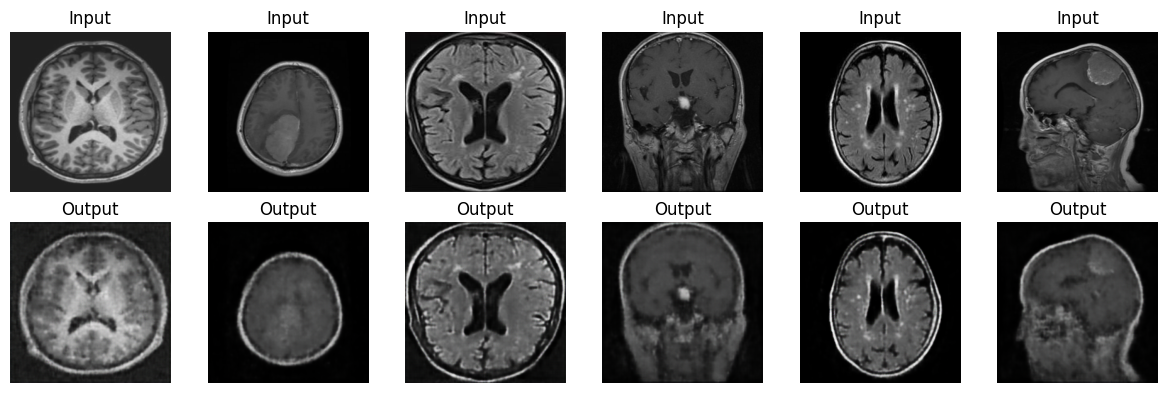

In [65]:

model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    outputs = model(images)

    inputs = images * 0.5 + 0.5
    recons = outputs * 0.5 + 0.5

    # show some original and reconstructed images
    fig, axes = plt.subplots(2, 6, figsize=(12, 4))
    for i in range(6):
        # Permute to change from [C, H, W] to [H, W, C]
        axes[0, i].imshow(inputs[i].cpu().permute(1, 2, 0).numpy())
        axes[0, i].set_title("Input")
        axes[0, i].axis("off")

        axes[1, i].imshow(recons[i].cpu().permute(1, 2, 0).numpy())
        axes[1, i].set_title("Output")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()



The quality of the reconstructed images is not perfect or highly detailed, but it is still a good representation of the input images. This indicates that most of the underlying information has been preserved by the encoder during compression.

In [ ]:
# recreate the model instance
model = Autoencoder(latent_dim=128)
model.load_state_dict(torch.load("Models/autoencoder.pth"))
model.eval()  


Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=131072, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(128, 32, 32))
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

## Encoder + Classifier, a classification model based on the latent dimension

### Building the model, training and testing

In [ ]:
encoder = model.encoder
classifier_model = TumorClassifier(encoder, latent_dim=128).to(device)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch import optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# As loss function, use BCEWithLogitsLoss
# As optimizer, use AdamW with weight decay
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(classifier_model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)  # solo classifier

num_epochs = 20

for epoch in range(num_epochs):
    classifier_model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)  # shape (B, 1)

        outputs = classifier_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)

    # ----------------------
    # Evaluation on validation set
    classifier_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = classifier_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            preds = torch.sigmoid(outputs) > 0.5  # Convert logits to binary predictions with a neutral threshold
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    # Computing the validation metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)


    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")


    # --------------------
# Final Test after training
classifier_model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = classifier_model(images)
        preds = torch.sigmoid(outputs) > 0.75 # convert logits to binary predictions with a threshold of 0.75
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Computing the test metrics
test_acc = accuracy_score(test_labels, test_preds)
test_prec = precision_score(test_labels, test_preds, zero_division=0)
test_rec = recall_score(test_labels, test_preds, zero_division=0)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)

print("\n📊 TEST SET PERFORMANCE")
print(f"Accuracy: {test_acc:.4f} | Precision: {test_prec:.4f} | Recall: {test_rec:.4f} | F1 Score: {test_f1:.4f}")



Epoch [1/20]
Train Loss: 0.6614 | Val Loss: 0.5991
Val Acc: 0.7781 | Prec: 0.8179 | Rec: 0.7794 | F1: 0.7982
Epoch [2/20]
Train Loss: 0.5801 | Val Loss: 0.5305
Val Acc: 0.8278 | Prec: 0.8688 | Rec: 0.8176 | F1: 0.8424
Epoch [3/20]
Train Loss: 0.5263 | Val Loss: 0.4820
Val Acc: 0.8609 | Prec: 0.8902 | Rec: 0.8588 | F1: 0.8743
Epoch [4/20]
Train Loss: 0.4759 | Val Loss: 0.4432
Val Acc: 0.8543 | Prec: 0.8865 | Rec: 0.8500 | F1: 0.8679
Epoch [5/20]
Train Loss: 0.4394 | Val Loss: 0.4111
Val Acc: 0.8659 | Prec: 0.8936 | Rec: 0.8647 | F1: 0.8789
Epoch [6/20]
Train Loss: 0.4125 | Val Loss: 0.3791
Val Acc: 0.8858 | Prec: 0.8950 | Rec: 0.9029 | F1: 0.8990
Epoch [7/20]
Train Loss: 0.3740 | Val Loss: 0.3547
Val Acc: 0.8891 | Prec: 0.8980 | Rec: 0.9059 | F1: 0.9019
Epoch [8/20]
Train Loss: 0.3532 | Val Loss: 0.3319
Val Acc: 0.9007 | Prec: 0.8955 | Rec: 0.9324 | F1: 0.9135
Epoch [9/20]
Train Loss: 0.3341 | Val Loss: 0.3153
Val Acc: 0.9123 | Prec: 0.9135 | Rec: 0.9324 | F1: 0.9229
Epoch [10/20]
Train

In order to choose the optimal threshold that balances the metrics according to our needs, we evaluate model performance over a range of thresholds. Given the medical context, where high recall is critical, this analysis helps us visualize how precision, recall, and other metrics change across different threshold values.

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classifier_model.eval()
all_probs_class_model = []
all_labels_class_model = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        outputs = classifier_model(images)
        probs = torch.sigmoid(outputs)
        
        all_probs_class_model.extend(probs.cpu().numpy())
        all_labels_class_model.extend(labels.cpu().numpy())

all_probs_class_model = np.array(all_probs_class_model).flatten()
all_labels_class_model = np.array(all_labels_class_model).flatten()

for threshold in list(np.arange(0.1, 1.0, 0.01)):
    preds = (all_probs_class_model > threshold).astype(int)
    acc = accuracy_score(all_labels_class_model, preds)
    prec = precision_score(all_labels_class_model, preds, zero_division=0)
    rec = recall_score(all_labels_class_model, preds, zero_division=0)
    f1 = f1_score(all_labels_class_model, preds, zero_division=0)
    print(f"Threshold: {threshold:.2f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")


Threshold: 0.10 | Acc: 0.8341 | Prec: 0.7637 | Rec: 1.0000 | F1: 0.8660
Threshold: 0.11 | Acc: 0.8462 | Prec: 0.7770 | Rec: 1.0000 | F1: 0.8745
Threshold: 0.12 | Acc: 0.8582 | Prec: 0.7929 | Rec: 0.9955 | F1: 0.8827
Threshold: 0.13 | Acc: 0.8678 | Prec: 0.8043 | Rec: 0.9955 | F1: 0.8898
Threshold: 0.14 | Acc: 0.8750 | Prec: 0.8132 | Rec: 0.9955 | F1: 0.8952
Threshold: 0.15 | Acc: 0.8846 | Prec: 0.8253 | Rec: 0.9955 | F1: 0.9024
Threshold: 0.16 | Acc: 0.8942 | Prec: 0.8377 | Rec: 0.9955 | F1: 0.9098
Threshold: 0.17 | Acc: 0.8966 | Prec: 0.8409 | Rec: 0.9955 | F1: 0.9117
Threshold: 0.18 | Acc: 0.9014 | Prec: 0.8473 | Rec: 0.9955 | F1: 0.9155
Threshold: 0.19 | Acc: 0.9014 | Prec: 0.8473 | Rec: 0.9955 | F1: 0.9155
Threshold: 0.20 | Acc: 0.9062 | Prec: 0.8538 | Rec: 0.9955 | F1: 0.9193
Threshold: 0.21 | Acc: 0.9135 | Prec: 0.8638 | Rec: 0.9955 | F1: 0.9250
Threshold: 0.22 | Acc: 0.9159 | Prec: 0.8672 | Rec: 0.9955 | F1: 0.9269
Threshold: 0.23 | Acc: 0.9135 | Prec: 0.8667 | Rec: 0.9910 | F1:

The optimal threshold was found to be 0.33, yielding the following performance metrics:

Accuracy: 0.9327 | Precision: 0.9012 | Recall: 0.9821 | F1-score: 0.9399

TP: 219, TN: 169, FP: 24, FN: 4
Accuracy: 0.9327
Precision: 0.9012
Recall: 0.9821
F1-score: 0.9399


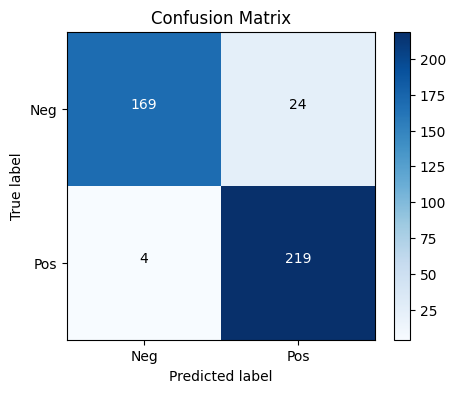

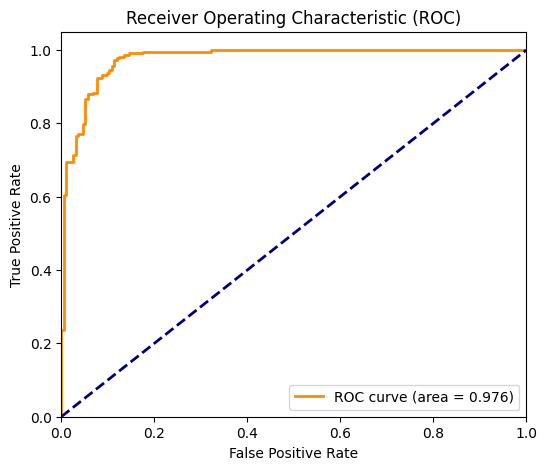

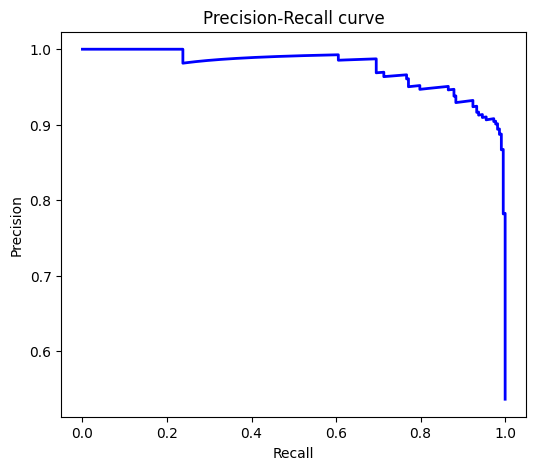

In [75]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

classifier_model.eval()
all_preds_class_model = []
all_probs_class_model = []   
all_labels_class_model = []

# Final evaluation on the test set with the optimal threshold (0.33)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = classifier_model(images)
        probs = torch.sigmoid(outputs)  
        preds = probs > 0.33              

        all_probs_class_model.extend(probs.cpu().numpy())
        all_preds_class_model.extend(preds.cpu().numpy())
        all_labels_class_model.extend(labels.cpu().numpy())

all_preds_class_model = np.array(all_preds_class_model).astype(int)
all_labels_class_model = np.array(all_labels_class_model).astype(int)
all_probs_class_model = np.array(all_probs_class_model)

# Computing TP, TN, FP, FN
TP = ((all_preds_class_model == 1) & (all_labels_class_model == 1)).sum()
TN = ((all_preds_class_model == 0) & (all_labels_class_model == 0)).sum()
FP = ((all_preds_class_model == 1) & (all_labels_class_model == 0)).sum()
FN = ((all_preds_class_model == 0) & (all_labels_class_model == 1)).sum()

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

# Base metrics
acc = (TP + TN) / (TP + TN + FP + FN + 1e-8)
prec = TP / (TP + FP + 1e-8)
rec = TP / (TP + FN + 1e-8)
f1 = 2 * prec * rec / (prec + rec + 1e-8)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion matrix and heatmap
cm = confusion_matrix(all_labels_class_model, all_preds_class_model)
plt.figure(figsize=(5,4))
plt.title("Confusion Matrix")
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Neg', 'Pos'])
plt.yticks(tick_marks, ['Neg', 'Pos'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(all_labels_class_model, all_probs_class_model)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(all_labels_class_model, all_probs_class_model)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()


In [11]:
torch.save(classifier_model.state_dict(), "autoencoder_classifier.pth")


In [ ]:
classifier_model =  TumorClassifier(encoder = model.encoder, latent_dim=128)
classifier_model.load_state_dict(torch.load("Models/autoencoder_classifier.pth"))
classifier_model.eval()  

TumorClassifier(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): 

### Interpretation Techniques 

#### Shap

Our model makes predictions based on compressed representations in the latent space. SHAP values help us understand which pixels in the original images contribute most to the classification by highlighting the areas that influence the latent patterns critical for the decision. Thus, SHAP links pixel-level features to the meaningful latent features driving the model’s output.

Type of shap_values: <class 'numpy.ndarray'>
Shape of shap_values: (10, 3, 256, 256, 1)
Final shape of shap_values: (10, 3, 256, 256, 1)
Shape of test_images: torch.Size([10, 3, 256, 256])
Shape of shap_values after conversion: (10, 3, 256, 256, 1)
Final shape of shap_values_vis: (10, 256, 256, 3)
Shape of test_images_np: (10, 256, 256, 3)


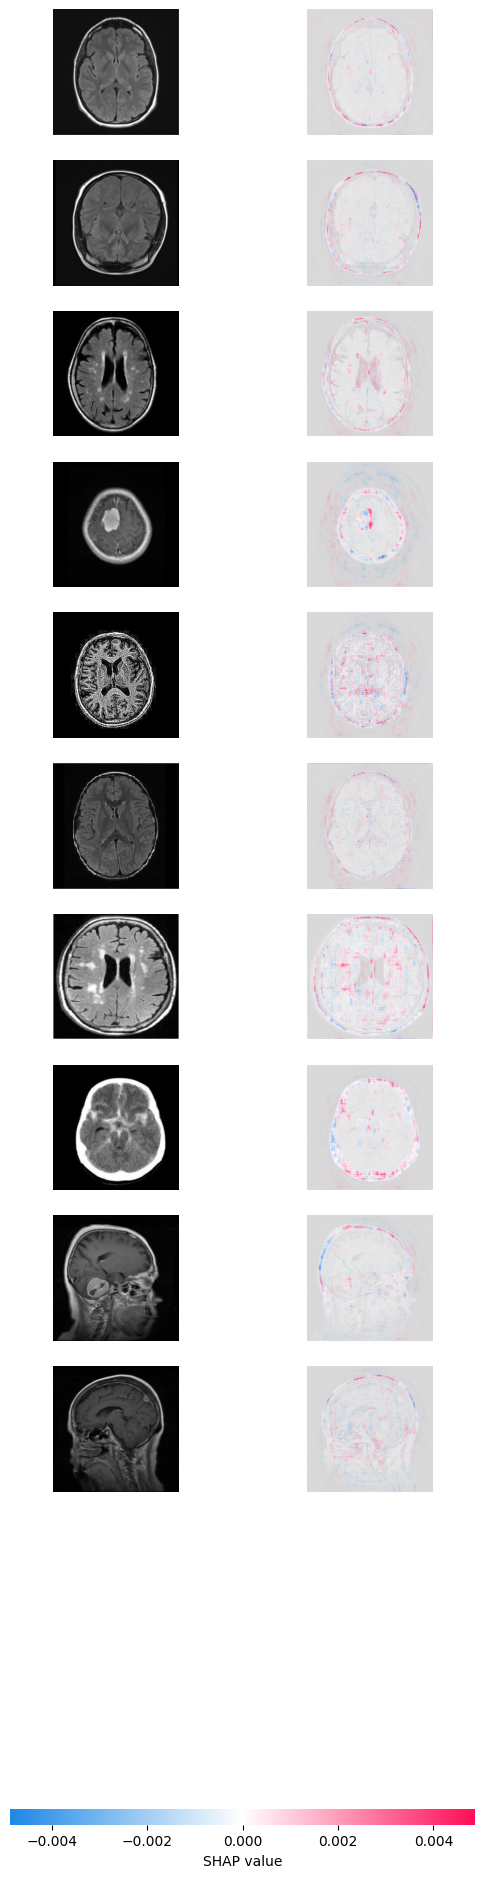

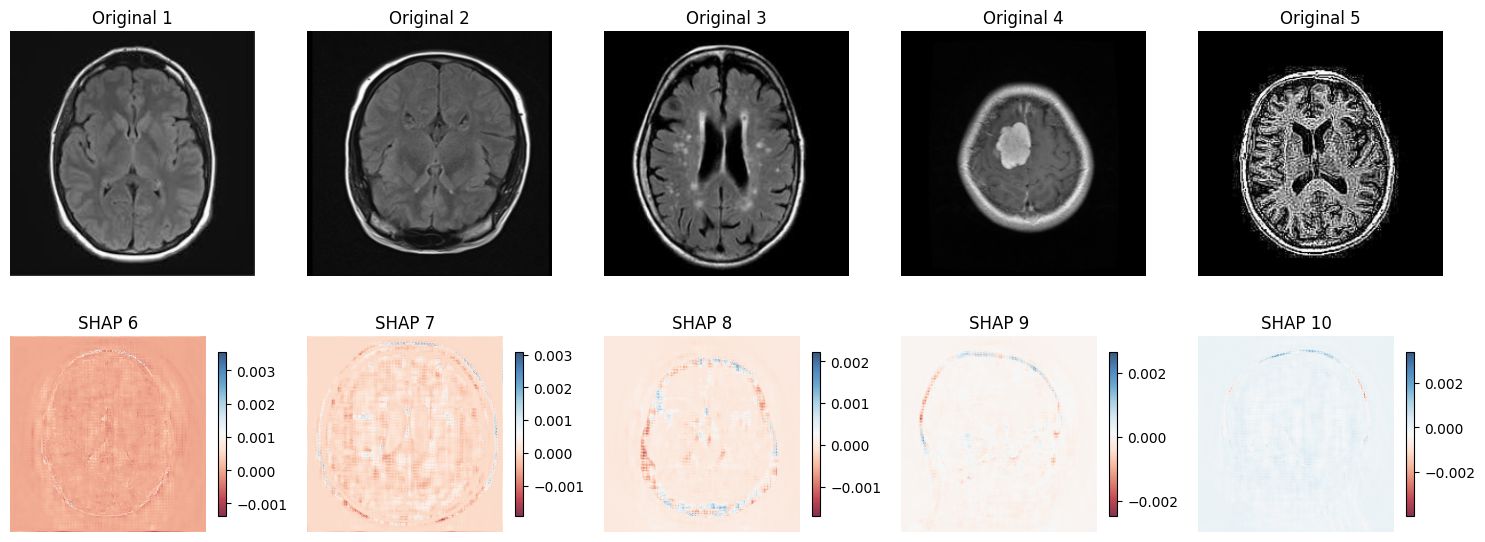

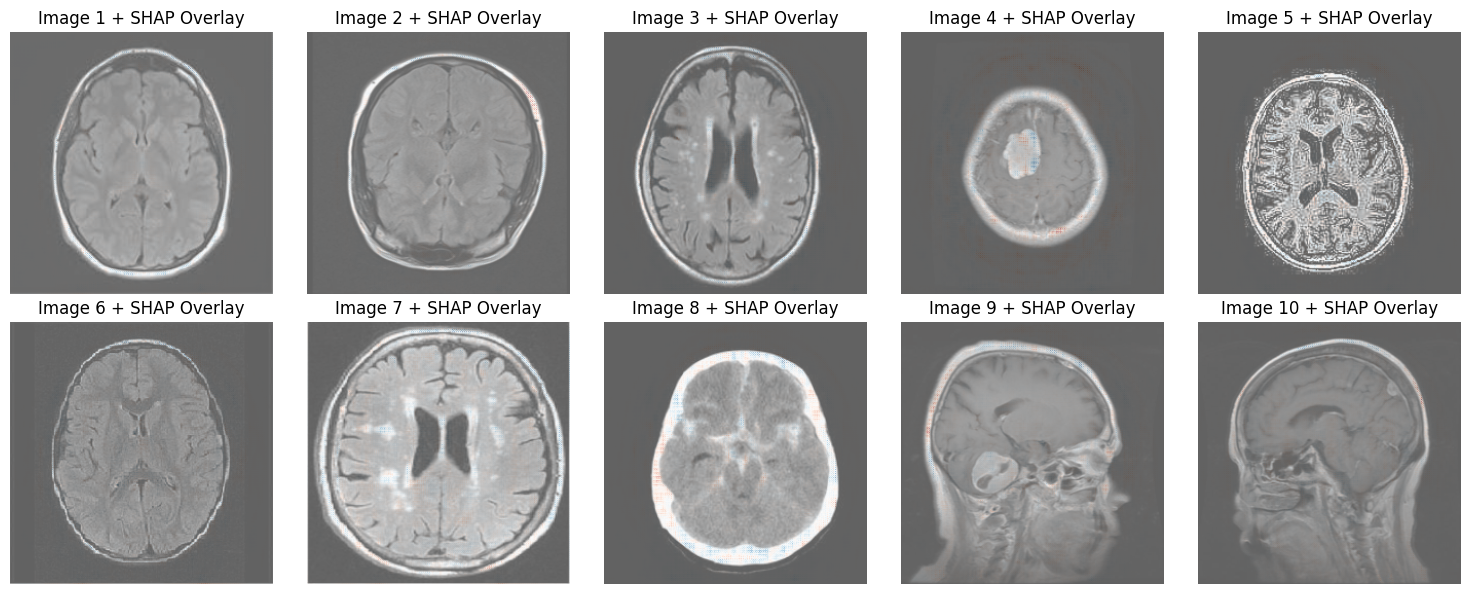

In [ ]:
import shap

# Set the classifier model to evaluation mode 
classifier_model.eval()
classifier_model.to(device)

# Instantiate the wrapped model and move it to device
wrapped_model = WrappedModel(classifier_model).to(device)
wrapped_model.eval()


# Prepare background data and test images for SHAP
background_data, _ = get_images_from_loader(test_loader, 50)
# Collect more images and randomly sample 20 from them
all_images = []
all_labels = []
with torch.no_grad():
    for x, y in test_loader:
        all_images.append(x)
        all_labels.append(y)
        if len(torch.cat(all_images)) >= 100:
            break

# Concatenate and randomly sample 20
all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)

indices = torch.randperm(all_images.size(0))[:10]
test_images = all_images[indices].to(device)
test_labels = all_labels[indices].to(device)

# Create a SHAP DeepExplainer with the wrapped model and background dataset
explainer = shap.DeepExplainer(wrapped_model, background_data)

# Compute SHAP values for the test images
shap_values = explainer.shap_values(test_images)

# Debug output: check SHAP value types and shapes
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Length of shap_values list: {len(shap_values)}")
    for i, sv in enumerate(shap_values):
        print(f"Shape of shap_values[{i}]: {sv.shape}")
    shap_values = shap_values[0]
else:
    print(f"Shape of shap_values: {shap_values.shape}")

print(f"Final shape of shap_values: {shap_values.shape}")
print(f"Shape of test_images: {test_images.shape}")

# Move test images to CPU and convert to NumPy format for visualization
# Change shape from [B, C, H, W] to [B, H, W, C]
test_images_np = test_images.cpu().numpy().transpose(0, 2, 3, 1)
# De-normalize from [-1, 1] to [0, 1]
test_images_np = (test_images_np * 0.5) + 0.5

# Convert SHAP values to NumPy if they are still torch tensors
if hasattr(shap_values, 'cpu'):
    shap_values = shap_values.cpu().numpy()

print(f"Shape of shap_values after conversion: {shap_values.shape}")

# Remove extra dimension if present and transpose for visualization
# From (10, 3, 256, 256, 1) → (10, 256, 256, 3)
if len(shap_values.shape) == 5:
    shap_values = shap_values.squeeze(-1)
    shap_values_vis = shap_values.transpose(0, 2, 3, 1)
elif len(shap_values.shape) == 4 and shap_values.shape[1] == test_images.shape[1]:
    shap_values_vis = shap_values.transpose(0, 2, 3, 1)
else:
    shap_values_vis = shap_values

print(f"Final shape of shap_values_vis: {shap_values_vis.shape}")
print(f"Shape of test_images_np: {test_images_np.shape}")

# SHAP visualization using built-in image plot
shap.image_plot(shap_values_vis, test_images_np)

# Alternative custom visualization: original and SHAP images side by side
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(min(10, len(test_images_np))):
    row = i // 5
    col = i % 5
    
    # Original image
    if row == 0:
        axes[row, col].imshow(test_images_np[i])
        axes[row, col].set_title(f'Original {i+1}')
        axes[row, col].axis('off')
    else:
        # SHAP value visualization
        shap_img = shap_values_vis[i]
        
        # Convert to grayscale by averaging across RGB channels if necessary
        if len(shap_img.shape) == 3 and shap_img.shape[2] == 3:
            shap_img = np.mean(shap_img, axis=2)
        elif len(shap_img.shape) == 3 and shap_img.shape[2] == 1:
            shap_img = shap_img[:, :, 0]
        
        im = axes[row, col].imshow(shap_img, cmap='RdBu', alpha=0.8)
        axes[row, col].set_title(f'SHAP {i+1}')
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col], shrink=0.6)

plt.tight_layout()
plt.show()

# Alternative overlay visualization: SHAP on top of the original image
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(min(10, len(test_images_np))):
    row = i // 5
    col = i % 5
    
    # Show original image
    axes[row, col].imshow(test_images_np[i])
    
    # Create SHAP overlay
    shap_img = shap_values_vis[i]
    if len(shap_img.shape) == 3 and shap_img.shape[2] == 3:
        shap_img = np.mean(shap_img, axis=2)
    elif len(shap_img.shape) == 3 and shap_img.shape[2] == 1:
        shap_img = shap_img[:, :, 0]
    
    # Normalize SHAP values for better visual contrast
    shap_img_norm = np.abs(shap_img)
    shap_img_norm = (shap_img_norm - shap_img_norm.min()) / (shap_img_norm.max() - shap_img_norm.min())
    
    im = axes[row, col].imshow(shap_img, cmap='RdBu', alpha=0.4, 
                               vmin=-np.abs(shap_img).max(), vmax=np.abs(shap_img).max())
    axes[row, col].set_title(f'Image {i+1} + SHAP Overlay')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


The SHAP visualizations suggest that the model tends to focus on the skull area, or more generally on regions where bright structures are surrounded by darker contrasts. While this is only our interpretation, it may indicate that the latent space has learned to identify such contrast patterns, which often resemble the appearance of tumors. However, SHAP values remain relatively low, so while this perspective offers useful insight into the network’s reasoning, it does not fully explain its decision-making process.


#### Conformal prediction 

This code applies Conformal Prediction to assess and quantify the uncertainty of a classification model. The idea is to not just make a single prediction, but to output a set of possible labels for each input, with a statistical guarantee that the true label is included in that set with high probability.

We first calibrate the model using a separate dataset to compute nonconformity scores, which measure how unusual each prediction is. Based on these scores, we determine a threshold (q_hat) that controls the size of the prediction sets. Then, when testing the model, we include all labels whose associated scores fall below this threshold.

The results tell us how often the true label is correctly included (empirical coverage), and how large the prediction sets tend to be. A well-calibrated model should meet the expected coverage.


Significance Level (alpha): 0.1
Desired Coverage: 0.9
Number of calibration scores: 339
Quantile index: 305
Calculated q_hat (threshold): 0.4438

Conformal Prediction Results:
Total samples in final test set: 416
Empirical Coverage: 0.9135 (Expected: >= 0.9)
Average Prediction Set Size: 0.9808


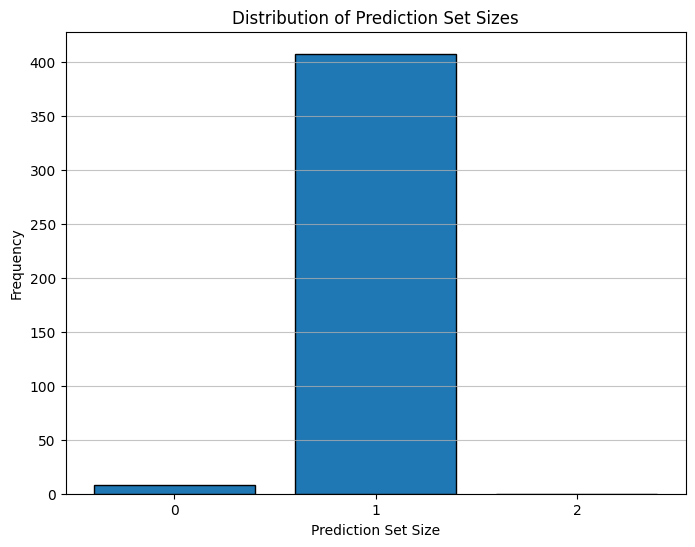

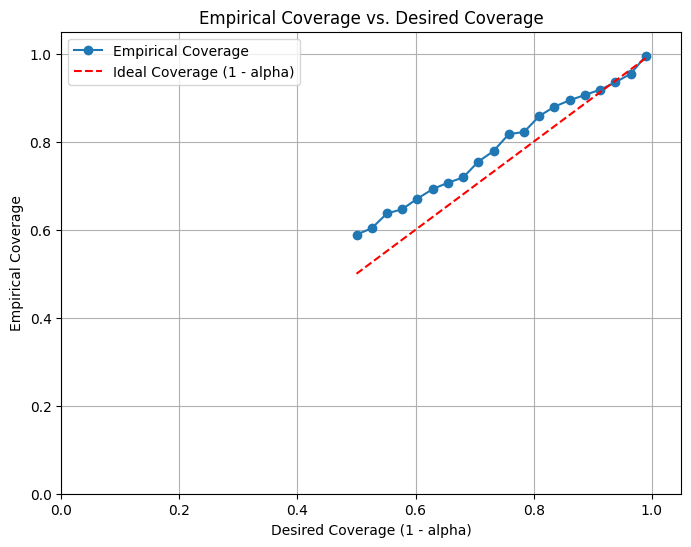

In [69]:
# set a seed for reproducibility
import random
import numpy as np
import torch

seed = 123
random.seed(seed)   
np.random.seed(seed)
torch.manual_seed(seed)


conformal_prediction(
    model=classifier_model,
    alpha=0.1,  # Significance level
    calibration_loader=calibration_loader,
    test_loader=test_loader,
    device=device
)

These results show that with a significance level (alpha) of 0.1, the method aims for 90% coverage. The empirical coverage of 91.35% exceeds this target, indicating the conformal prediction sets reliably include the true label. The average prediction set size is just under 1, meaning most predictions are confident single-class sets, reflecting good model certainty.



The next code plots a comparison between the model's confidence on correct vs. incorrect predictions. Ideally, correct predictions show higher confidence. If not, the model may be overconfident or poorly calibrated. It helps assess how reliable the confidence scores are.

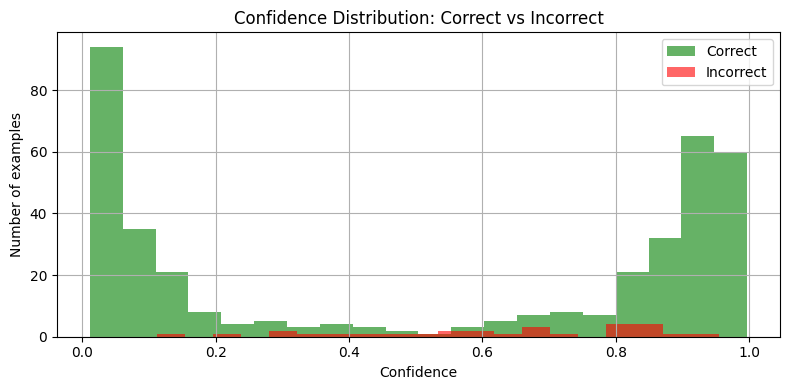

In [79]:
all_preds_class_model = np.array(all_preds_class_model).flatten()
all_labels_class_model = np.array(all_labels_class_model).flatten()

correct = all_preds_class_model == all_labels_class_model
incorrect = ~correct

plt.figure(figsize=(8, 4))
plt.hist(all_probs_class_model[correct], bins=20, alpha=0.6, label="Correct", color='green')
plt.hist(all_probs_class_model[incorrect], bins=20, alpha=0.6, label="Incorrect", color='red')
plt.xlabel("Confidence")
plt.ylabel("Number of examples")
plt.title("Confidence Distribution: Correct vs Incorrect")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## DDPM, implementation and training

This approach outlines the construction of a DDPM model, which will later be useful for reconstructing noisy latent spaces. The key concepts introduced here will also inform the design of the subsequent classifier, enabling it to perform classification while accounting for noise in the latent representations.

In [ ]:
import torch
import torch.nn as nn

T = 1000  # total diffusion steps
betas = linear_beta_schedule(T)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [80]:
train_denoiser_model = train_denoiser(model, train_loader, latent_dim=128, device=device, epochs = 20)

Starting Probabilistic Denoiser Training...
Epoch 1: Avg Probabilistic Denoiser Loss = 0.650860
Epoch 2: Avg Probabilistic Denoiser Loss = 0.546418
Epoch 3: Avg Probabilistic Denoiser Loss = 0.522366
Epoch 4: Avg Probabilistic Denoiser Loss = 0.514077
Epoch 5: Avg Probabilistic Denoiser Loss = 0.509894
Epoch 6: Avg Probabilistic Denoiser Loss = 0.506672
Epoch 7: Avg Probabilistic Denoiser Loss = 0.504654
Epoch 8: Avg Probabilistic Denoiser Loss = 0.502532
Epoch 9: Avg Probabilistic Denoiser Loss = 0.503654
Epoch 10: Avg Probabilistic Denoiser Loss = 0.499093
Epoch 11: Avg Probabilistic Denoiser Loss = 0.500561
Epoch 12: Avg Probabilistic Denoiser Loss = 0.497055
Epoch 13: Avg Probabilistic Denoiser Loss = 0.494825
Epoch 14: Avg Probabilistic Denoiser Loss = 0.493657
Epoch 15: Avg Probabilistic Denoiser Loss = 0.491273
Epoch 16: Avg Probabilistic Denoiser Loss = 0.482502
Epoch 17: Avg Probabilistic Denoiser Loss = 0.476445
Epoch 18: Avg Probabilistic Denoiser Loss = 0.471913
Epoch 19: A

In [81]:
torch.save(train_denoiser_model.state_dict(), "DDM.pth")


In [ ]:
train_denoiser_model =  LatentDenoiserResidual(latent_dim=128)
train_denoiser_model.load_state_dict(torch.load("Models/DDM.pth"))
train_denoiser_model.eval()  

LatentDenoiserResidual(
  (time_embed): SinusoidalTimeEmbedding()
  (input_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (input_linear): Linear(in_features=256, out_features=512, bias=True)
  (res1): ResidualBlock(
    (block): Sequential(
      (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (5): SiLU()
      (6): Dropout(p=0.1, inplace=False)
      (7): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (res2): ResidualBlock(
    (block): Sequential(
      (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (5): SiLU()
      (6): Dropout(p=0.1, inplace=Fa

## Noise-Aware Latent Classifier

### Model setup and training

As written above, here a classifier that works with noised latent vector is implemented. The idea is to create a model that is robust to noise, and that performes better than any other in this difficutl task

In [15]:
ddm_classifier_model = train_ddm_classifier(
    autoencoder=model,
    train_loader=train_loader,
    val_loader=val_loader,
    latent_dim=128,
    num_classes=2,  
    device=device,
    T=T,
    alphas_cumprod=alphas_cumprod,
    q_sample=q_sample,
    epochs=100  
)

evaluate_classifier(
    classifier=ddm_classifier_model,
    autoencoder=model,
    test_loader=test_loader,
    device=device,
    T=T,
    alphas_cumprod=alphas_cumprod,
    q_sample=q_sample
)

Starting DDM Classifier Training for 100 epochs (Only Classification Loss)...
Classifier architecture: LatentClassifierResidual(
  (time_embed): SinusoidalTimeEmbedding()
  (input_linear): Linear(in_features=128, out_features=128, bias=True)
  (time_linear): Linear(in_features=64, out_features=128, bias=True)
  (initial_bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (act1): ReLU()
  (middle_linear): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (act2): ReLU()
  (classification_head): Linear(in_features=64, out_features=1, bias=True)
  (noise_mu_logvar_head): Linear(in_features=64, out_features=256, bias=True)
)
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas

(0.9254807692307693,
 0.9067796610169492,
 0.9596412556053812,
 0.9324618736383442)

Threshold selection for metric trade-offs

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score


ddm_classifier_model.eval()
all_probs_ddm_model = []
all_labels_ddm_model = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        z_0 = model.encoder(images)

        t = torch.randint(0, T, (images.size(0),), device=device)
        noise = torch.randn_like(z_0)
        z_t = q_sample(z_0, t, noise, alphas_cumprod)

        logits, mu_pred, std_pred = ddm_classifier_model(z_t, t)
        probs = torch.sigmoid(logits)

        all_probs_ddm_model.extend(probs.cpu().numpy())
        all_labels_ddm_model.extend(labels.cpu().numpy())

# 📊 Calcolo metriche per varie soglie
all_probs_ddm_model = np.array(all_probs_ddm_model).flatten()
all_labels_ddm_model = np.array(all_labels_ddm_model).flatten()

for threshold in np.arange(0.1, 1.0, 0.01):
    preds = (all_probs_ddm_model > threshold).astype(int)
    acc = accuracy_score(all_labels_ddm_model, preds)
    prec = precision_score(all_labels_ddm_model, preds, zero_division=0)
    rec = recall_score(all_labels_ddm_model, preds, zero_division=0)
    f1 = f1_score(all_labels_ddm_model, preds, zero_division=0)
    print(f"Threshold: {threshold:.2f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")


Threshold: 0.10 | Acc: 0.8365 | Prec: 0.7700 | Rec: 0.9910 | F1: 0.8667
Threshold: 0.11 | Acc: 0.8389 | Prec: 0.7727 | Rec: 0.9910 | F1: 0.8684
Threshold: 0.12 | Acc: 0.8438 | Prec: 0.7782 | Rec: 0.9910 | F1: 0.8718
Threshold: 0.13 | Acc: 0.8438 | Prec: 0.7782 | Rec: 0.9910 | F1: 0.8718
Threshold: 0.14 | Acc: 0.8413 | Prec: 0.7774 | Rec: 0.9865 | F1: 0.8696
Threshold: 0.15 | Acc: 0.8438 | Prec: 0.7801 | Rec: 0.9865 | F1: 0.8713
Threshold: 0.16 | Acc: 0.8462 | Prec: 0.7829 | Rec: 0.9865 | F1: 0.8730
Threshold: 0.17 | Acc: 0.8534 | Prec: 0.7914 | Rec: 0.9865 | F1: 0.8782
Threshold: 0.18 | Acc: 0.8582 | Prec: 0.7971 | Rec: 0.9865 | F1: 0.8818
Threshold: 0.19 | Acc: 0.8606 | Prec: 0.8000 | Rec: 0.9865 | F1: 0.8835
Threshold: 0.20 | Acc: 0.8606 | Prec: 0.8000 | Rec: 0.9865 | F1: 0.8835
Threshold: 0.21 | Acc: 0.8678 | Prec: 0.8088 | Rec: 0.9865 | F1: 0.8889
Threshold: 0.22 | Acc: 0.8702 | Prec: 0.8118 | Rec: 0.9865 | F1: 0.8907
Threshold: 0.23 | Acc: 0.8702 | Prec: 0.8141 | Rec: 0.9821 | F1:

The best threshold was the 0.47, with the following metrics:

Acc: 0.9327 | Prec: 0.9149 | Rec: 0.9641 | F1: 0.9389


In [22]:
torch.save(ddm_classifier_model.state_dict(), "DDM_classifier.pth")

In [ ]:
ddm_classifier_model =  LatentClassifierResidual(latent_dim=128, num_classes=2)
ddm_classifier_model.load_state_dict(torch.load("Models/DDM_classifier.pth"))
ddm_classifier_model.eval()  

LatentClassifierResidual(
  (time_embed): SinusoidalTimeEmbedding()
  (input_linear): Linear(in_features=128, out_features=128, bias=True)
  (time_linear): Linear(in_features=64, out_features=128, bias=True)
  (initial_bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (act1): ReLU()
  (middle_linear): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (act2): ReLU()
  (classification_head): Linear(in_features=64, out_features=1, bias=True)
  (noise_mu_logvar_head): Linear(in_features=64, out_features=256, bias=True)
)

### Evaluation of the performance under noisy data

The model classifies while taking into account the noise level 𝑡 present in the latent dimension.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, precision_recall_fscore_support

ddm_classifier_model.eval()  # Set the DDM classifier to evaluation mode
timesteps_to_test = np.linspace(0, T-1, 10, dtype=int)  # Select 10 timesteps evenly spaced from 0 to T-1
threshold = 0.47  # Classification threshold (adjust if necessary)

# List to store evaluation metrics and predictions for each timestep
results_1 = []

for timestep in timesteps_to_test:
    print(f"\n=== Timestep: {timestep} ===")

    # Initialize lists to collect predictions, probabilities, and true labels for the current timestep
    all_preds_ddm_model = []
    all_probs_ddm_model = []
    all_labels_ddm_model = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            z_0 = model.encoder(images)  # Encode images to latent space

            # Create a tensor filled with the current timestep for all batch elements
            t = torch.full((images.size(0),), timestep, device=device, dtype=torch.long)
            noise = torch.randn_like(z_0)  # Generate Gaussian noise
            z_t = q_sample(z_0, t, noise, alphas_cumprod)  # Diffuse latent vectors to timestep t

            # Get classification logits and noise predictions from the DDM classifier
            logits, mu_pred, std_pred = ddm_classifier_model(z_t, t)
            probs = torch.sigmoid(logits)  # Convert logits to probabilities
            preds = (probs > threshold).int()  # Apply threshold to get binary predictions

            # Accumulate predictions, probabilities, and labels (move tensors to CPU and convert to numpy)
            all_probs_ddm_model.extend(probs.cpu().numpy())
            all_preds_ddm_model.extend(preds.cpu().numpy())
            all_labels_ddm_model.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays and ensure correct type
    all_preds_ddm_model = np.array(all_preds_ddm_model).astype(int)
    all_labels_ddm_model = np.array(all_labels_ddm_model).astype(int)
    all_probs_ddm_model = np.array(all_probs_ddm_model)

    # Compute metrics for the current timestep
    acc = accuracy_score(all_labels_ddm_model, all_preds_ddm_model)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels_ddm_model, all_preds_ddm_model, average="weighted", zero_division=0
    )

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # Store results for this timestep for further analysis or plotting
    results_1.append({
        "timestep": timestep,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "probs_ddm_model": all_probs_ddm_model,
        "labels_ddm_model": all_labels_ddm_model
    })



=== Timestep: 0 ===
Accuracy: 0.9639, Precision: 0.9640, Recall: 0.9639, F1: 0.9639

=== Timestep: 111 ===
Accuracy: 0.9639, Precision: 0.9640, Recall: 0.9639, F1: 0.9639

=== Timestep: 222 ===
Accuracy: 0.9663, Precision: 0.9665, Recall: 0.9663, F1: 0.9663

=== Timestep: 333 ===
Accuracy: 0.9663, Precision: 0.9665, Recall: 0.9663, F1: 0.9663

=== Timestep: 444 ===
Accuracy: 0.9639, Precision: 0.9644, Recall: 0.9639, F1: 0.9639

=== Timestep: 555 ===
Accuracy: 0.9543, Precision: 0.9554, Recall: 0.9543, F1: 0.9542

=== Timestep: 666 ===
Accuracy: 0.9255, Precision: 0.9264, Recall: 0.9255, F1: 0.9253

=== Timestep: 777 ===
Accuracy: 0.9062, Precision: 0.9147, Recall: 0.9062, F1: 0.9052

=== Timestep: 888 ===
Accuracy: 0.7091, Precision: 0.7901, Recall: 0.7091, F1: 0.6783

=== Timestep: 999 ===
Accuracy: 0.6082, Precision: 0.6514, Recall: 0.6082, F1: 0.5555


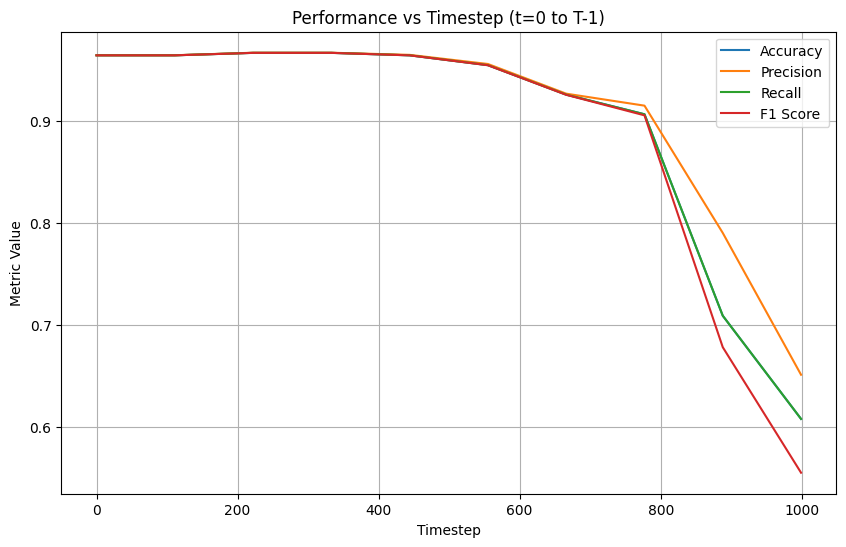

In [ ]:
timesteps = [r["timestep"] for r in results_1]
accuracies = [r["accuracy"] for r in results_1]
precisions = [r["precision"] for r in results_1]
recalls = [r["recall"] for r in results_1]
f1s = [r["f1"] for r in results_1]

plt.figure(figsize=(10,6))
plt.plot(timesteps, accuracies, label='Accuracy')
plt.plot(timesteps, precisions, label='Precision')
plt.plot(timesteps, recalls, label='Recall')
plt.plot(timesteps, f1s, label='F1 Score')
plt.xlabel("Timestep")
plt.ylabel("Metric Value")
plt.title("Performance vs Timestep (t=0 to T-1)")
plt.legend()
plt.grid(True)
plt.show()


In the next code, the model classifies while receiving noised inputs, but it always assumes these inputs are clean by using 𝑡 = 0 every time. 
This setup lets us test whether the model can detect and understand noise in the data even without explicitly being given the noise level 𝑡.

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, precision_recall_fscore_support

ddm_classifier_model.eval()  # Set the DDM classifier to evaluation mode
timesteps_to_test = np.linspace(0, T-1, 10, dtype=int)  # Select 10 timesteps evenly spaced between 0 and T-1
threshold = 0.47  # Classification threshold, adjust if necessary

# List to store evaluation metrics and predictions for each timestep
results_2 = []

for timestep in timesteps_to_test:
    print(f"\n=== Timestep: {timestep} ===")
    
    # Initialize lists to accumulate predictions, probabilities, and true labels for the current timestep
    all_preds_ddm_model = []
    all_probs_ddm_model = []
    all_labels_ddm_model = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            z_0 = model.encoder(images)  # Encode images into latent space

            # Create a tensor of the current timestep for all batch samples
            t = torch.full((images.size(0),), timestep, device=device, dtype=torch.long)
            noise = torch.randn_like(z_0)  # Sample Gaussian noise
            z_t = q_sample(z_0, t, noise, alphas_cumprod)  # Diffuse latent vectors to timestep t

            # NOTE: Here you are using a tensor with a single zero value for t, 
            # which might be a bug. Usually, t should be the current timestep.
            t_tensor = torch.tensor([0], device=z_t.device)  # Tensor with value 0 on the correct device
            
            # Forward pass through the classifier
            logits, mu_pred, std_pred = ddm_classifier_model(z_t, t_tensor)
            probs = torch.sigmoid(logits)  # Convert logits to probabilities
            preds = (probs > threshold).int()  # Threshold to get binary predictions

            # Accumulate predictions, probabilities, and labels, moving to CPU and converting to numpy
            all_probs_ddm_model.extend(probs.cpu().numpy())
            all_preds_ddm_model.extend(preds.cpu().numpy())
            all_labels_ddm_model.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays and ensure integer type
    all_preds_ddm_model = np.array(all_preds_ddm_model).astype(int)
    all_labels_ddm_model = np.array(all_labels_ddm_model).astype(int)
    all_probs_ddm_model = np.array(all_probs_ddm_model)

    # Compute performance metrics for the current timestep
    acc = accuracy_score(all_labels_ddm_model, all_preds_ddm_model)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels_ddm_model, all_preds_ddm_model, average="weighted", zero_division=0
    )

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # Store the metrics and predictions for this timestep for further analysis or visualization
    results_2.append({
        "timestep": timestep,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "probs_ddm_model": all_probs_ddm_model,
        "labels_ddm_model": all_labels_ddm_model
    })



=== Timestep: 0 ===
Accuracy: 0.9639, Precision: 0.9640, Recall: 0.9639, F1: 0.9639

=== Timestep: 111 ===
Accuracy: 0.9639, Precision: 0.9640, Recall: 0.9639, F1: 0.9639

=== Timestep: 222 ===
Accuracy: 0.9663, Precision: 0.9665, Recall: 0.9663, F1: 0.9663

=== Timestep: 333 ===
Accuracy: 0.9639, Precision: 0.9641, Recall: 0.9639, F1: 0.9639

=== Timestep: 444 ===
Accuracy: 0.9639, Precision: 0.9644, Recall: 0.9639, F1: 0.9639

=== Timestep: 555 ===
Accuracy: 0.9519, Precision: 0.9528, Recall: 0.9519, F1: 0.9518

=== Timestep: 666 ===
Accuracy: 0.9207, Precision: 0.9212, Recall: 0.9207, F1: 0.9205

=== Timestep: 777 ===
Accuracy: 0.8918, Precision: 0.8922, Recall: 0.8918, F1: 0.8919

=== Timestep: 888 ===
Accuracy: 0.7764, Precision: 0.8148, Recall: 0.7764, F1: 0.7729

=== Timestep: 999 ===
Accuracy: 0.5793, Precision: 0.6589, Recall: 0.5793, F1: 0.5425


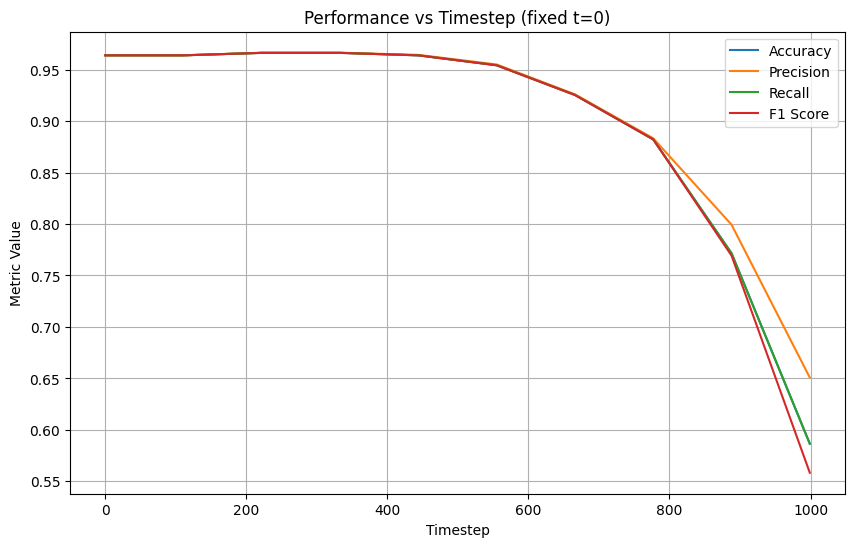

In [ ]:
timesteps = [r["timestep"] for r in results_2]
accuracies = [r["accuracy"] for r in results_2]
precisions = [r["precision"] for r in results_2]
recalls = [r["recall"] for r in results_2]
f1s = [r["f1"] for r in results_2]

plt.figure(figsize=(10,6))
plt.plot(timesteps, accuracies, label='Accuracy')
plt.plot(timesteps, precisions, label='Precision')
plt.plot(timesteps, recalls, label='Recall')
plt.plot(timesteps, f1s, label='F1 Score')
plt.xlabel("Timestep")
plt.ylabel("Metric Value")
plt.title("Performance vs Timestep (fixed t=0)")
plt.legend()
plt.grid(True)
plt.show()


More compact visualization of those results.

In [ ]:
T = 1000
timesteps_to_test = np.linspace(0, T-1, 10, dtype=int)  # 10 timesteps from 0 to T-1
test_across_timesteps(model, ddm_classifier_model, test_loader, alphas_cumprod, device, timesteps_to_test, t_stable=False)


Timestep | Accuracy | Precision |  Recall |     F1
--------------------------------------------------
       0 |   0.9639 |    0.9640 |  0.9639 | 0.9639
     111 |   0.9639 |    0.9640 |  0.9639 | 0.9639
     222 |   0.9663 |    0.9665 |  0.9663 | 0.9663
     333 |   0.9663 |    0.9665 |  0.9663 | 0.9663
     444 |   0.9615 |    0.9618 |  0.9615 | 0.9615
     555 |   0.9543 |    0.9550 |  0.9543 | 0.9542
     666 |   0.9231 |    0.9238 |  0.9231 | 0.9229
     777 |   0.9038 |    0.9086 |  0.9038 | 0.9031
     888 |   0.7308 |    0.8021 |  0.7308 | 0.7066
     999 |   0.6346 |    0.7095 |  0.6346 | 0.5814


In [86]:
test_across_timesteps(model, ddm_classifier_model, test_loader, alphas_cumprod, device, timesteps_to_test, t_stable=True)


Timestep | Accuracy | Precision |  Recall |     F1
--------------------------------------------------
       0 |   0.9639 |    0.9640 |  0.9639 | 0.9639
     111 |   0.9639 |    0.9640 |  0.9639 | 0.9639
     222 |   0.9663 |    0.9665 |  0.9663 | 0.9663
     333 |   0.9639 |    0.9641 |  0.9639 | 0.9639
     444 |   0.9639 |    0.9644 |  0.9639 | 0.9639
     555 |   0.9543 |    0.9554 |  0.9543 | 0.9542
     666 |   0.9231 |    0.9247 |  0.9231 | 0.9228
     777 |   0.8942 |    0.8942 |  0.8942 | 0.8942
     888 |   0.7476 |    0.7854 |  0.7476 | 0.7433
     999 |   0.5817 |    0.6715 |  0.5817 | 0.5417


Both variants of the classifier — with and without access to the correct noise level `t` — show strong robustness at low noise levels, maintaining high accuracy and F1 scores. As expected, performance gradually degrades at higher noise levels due to the increased difficulty in extracting meaningful features.

Remarkably, even when the classifier is not provided with the correct `t` (i.e., always assuming `t = 0`), it still performs well. This suggests that the model has learned to "see through the noise" and internally recognize the level of degradation in the latent space, allowing it to make accurate predictions without explicit knowledge of the noise schedule.


### Conformal Prediction


Significance Level (alpha): 0.1
Desired Coverage: 0.9
Number of calibration scores: 339
Quantile index: 305
Calculated q_hat (threshold): 0.4956

Conformal Prediction Results:
Total samples in final test set: 416
Empirical Coverage: 0.9038 (Expected: >= 0.9)
Average Prediction Set Size: 0.9832


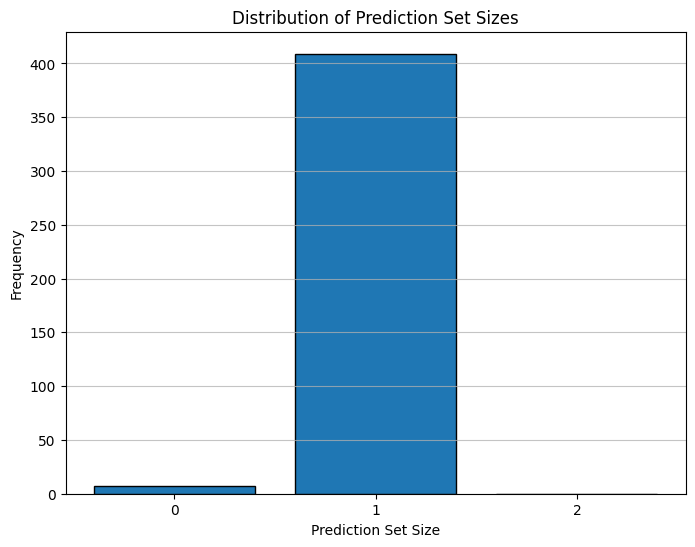

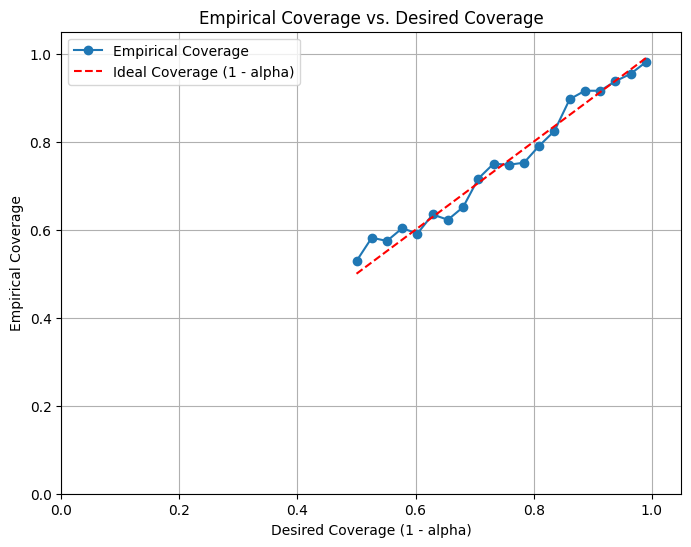

In [ ]:
conformal_prediction(
    model=ddm_classifier_model,
    alpha=0.1,  
    calibration_loader=calibration_loader,
    test_loader=test_loader,
    device=device,
    T=1000,  # number of diffusion steps
    autoencoder=model 
)

- **Significance Level (α):** 0.1  
- **Target Coverage:** 0.9  
- **Empirical Coverage:** 0.9038   
- **Average Prediction Set Size:** 0.9832  

Using 339 calibration scores, the conformal predictor achieves the expected coverage level using a quantile threshold (`q̂ ≈ 0.4956`).  
This ensures that the model’s prediction sets are reliably calibrated, with nearly all test examples producing **single-label** predictions (size ≈ 1), showing high confidence and minimal ambiguity.



=== Timestep: 0 ===


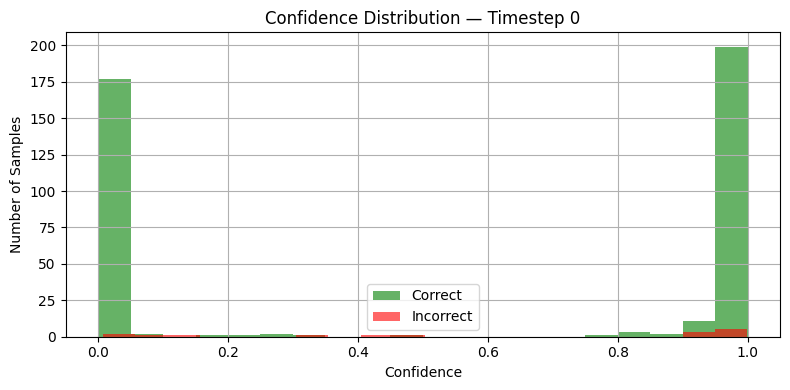


=== Timestep: 111 ===


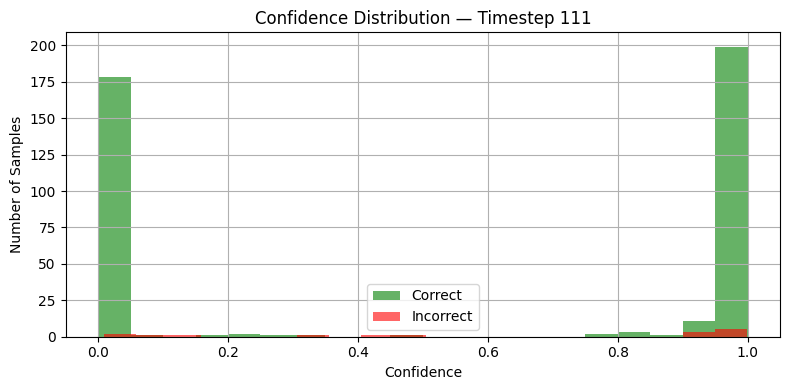


=== Timestep: 222 ===


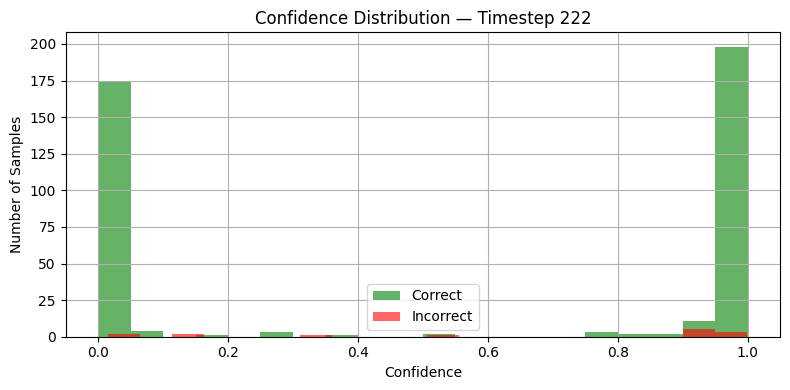


=== Timestep: 333 ===


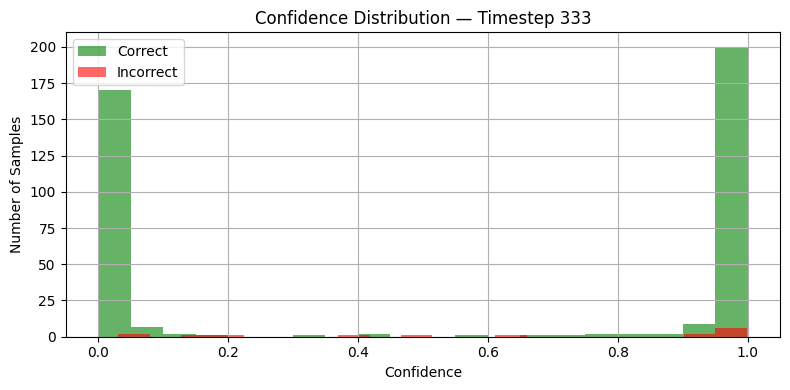


=== Timestep: 444 ===


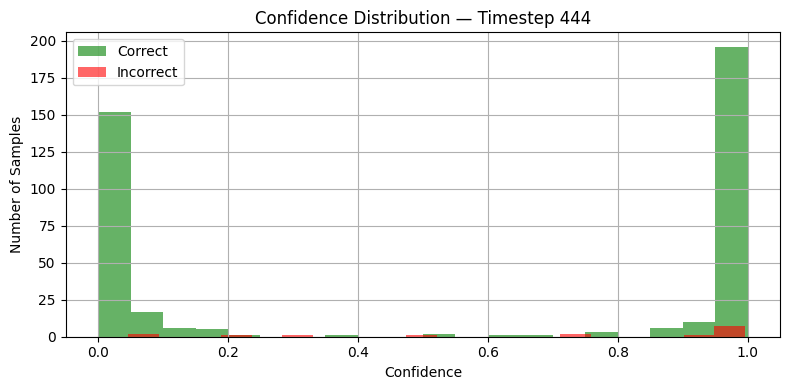


=== Timestep: 555 ===


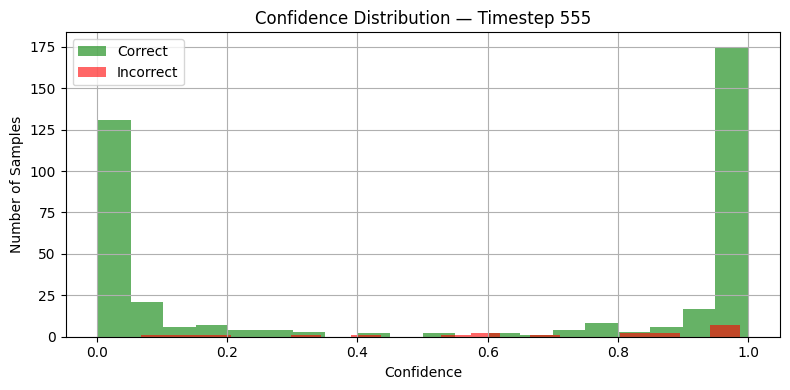


=== Timestep: 666 ===


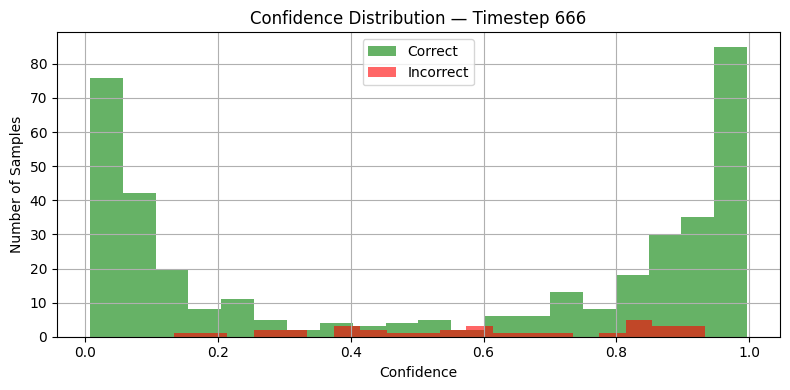


=== Timestep: 777 ===


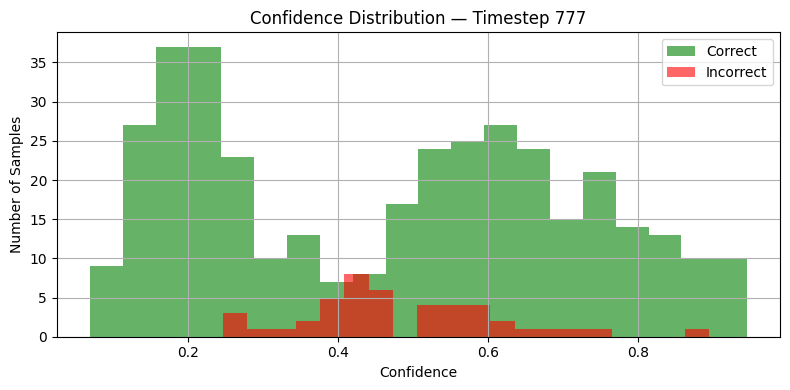


=== Timestep: 888 ===


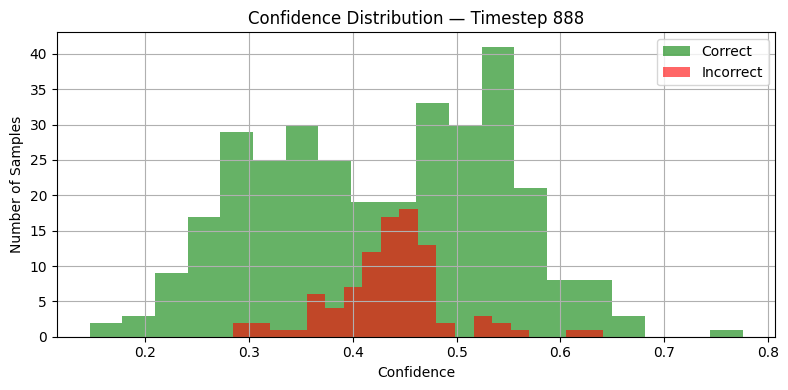


=== Timestep: 999 ===


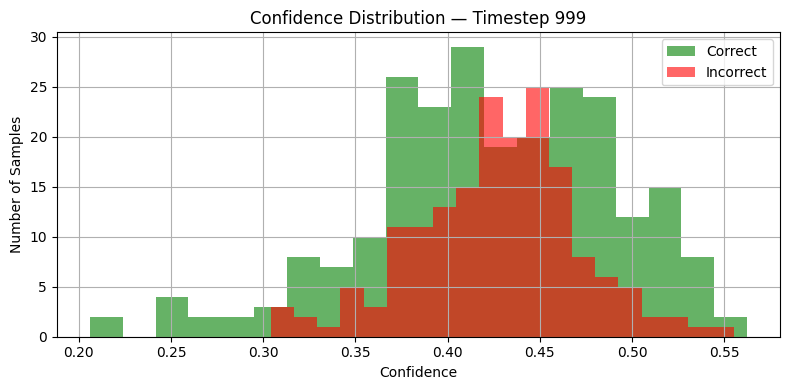

In [93]:
import matplotlib.pyplot as plt
import numpy as np

for result in results_2:
    timestep = result["timestep"]
    probs = np.array(result["probs_ddm_model"]).flatten()
    labels = np.array(result["labels_ddm_model"]).flatten()
    preds = (probs > threshold).astype(int)

    correct = preds == labels
    incorrect = ~correct

    print(f"\n=== Timestep: {timestep} ===")

    plt.figure(figsize=(8, 4))
    plt.hist(probs[correct], bins=20, alpha=0.6, label="Correct", color='green')
    plt.hist(probs[incorrect], bins=20, alpha=0.6, label="Incorrect", color='red')
    plt.xlabel("Confidence")
    plt.ylabel("Number of Samples")
    plt.title(f"Confidence Distribution — Timestep {timestep}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


The histograms visualize the model’s predicted confidence (sigmoid probabilities) across different noise levels (`timestep` values), distinguishing **correct** (green) and **incorrect** (red) predictions. We observed that:

- **Low noise levels (timestep < 600):**
  - Confidence is strongly **bimodal**, with most predictions near **0 or 1**.
  - **Correct predictions dominate** both extremes.
  - **Errors are rare**, and mostly occur not near 0 or 1, where the model is most confident.

- **Medium noise (timestep ≈ 600–777):**
  - The sharp peaks at 0 and 1 begin to flatten.
  - The model’s confidence becomes **less polarized**.
  - Errors become **slightly more frequent** but remain mostly in the central region.

- **High noise levels (timestep ≥ 777):**
  - The distribution becomes **almost flat**, resembling a **rectangular shape**.
  - Correct predictions become **more uniformly spread**, and **confidence calibration deteriorates**.
  - **Red bars (errors)** increase visibly and spread out, especially around the center, where uncertainty is highest.

The classifier gracefully degrades under strong noise. It demonstrates the ability to:
- Detect and **adapt to the noise level implicitly**, and  
- Make decisions aligned with its confidence — **low confidence correlates with higher error**, which is a desirable and interpretable behavior.


## Comparison between Encoder + Classifier and Noise-Aware Classifier 

It is important to provide evidence of our model's robustness to noise by comparing its performance to a baseline that does not explicitly account for noise levels. To do this, we evaluate the model trained with diffusion-aware features (DDM Classifier) against our original TumorClassifier, which operates directly on autoencoder latents without conditioning on the noise level t.

In [ ]:
results_comparison = evaluate_model_under_noise(ddm_classifier_model, classifier_model, model, test_loader, device, latent_dim=128, alphas_cumprod=alphas_cumprod, q_sample=q_sample )

In [97]:
print_comparison(results_comparison)

Timestep |    Model |    Acc |   Prec | Recall |     F1
--------------------------------------------------------
       0 |      DDM | 0.9639 | 0.9640 | 0.9639 | 0.9639
       0 |      CNN | 0.9327 | 0.9363 | 0.9327 | 0.9323
     100 |      DDM | 0.9615 | 0.9616 | 0.9615 | 0.9615
     100 |      CNN | 0.7356 | 0.7754 | 0.7356 | 0.7305
     200 |      DDM | 0.9663 | 0.9665 | 0.9663 | 0.9663
     200 |      CNN | 0.7812 | 0.7890 | 0.7812 | 0.7813
     300 |      DDM | 0.9663 | 0.9665 | 0.9663 | 0.9663
     300 |      CNN | 0.7716 | 0.7761 | 0.7716 | 0.7688
     400 |      DDM | 0.9663 | 0.9667 | 0.9663 | 0.9663
     400 |      CNN | 0.7452 | 0.7641 | 0.7452 | 0.7364
     500 |      DDM | 0.9639 | 0.9647 | 0.9639 | 0.9639
     500 |      CNN | 0.7404 | 0.7695 | 0.7404 | 0.7281
     600 |      DDM | 0.9471 | 0.9484 | 0.9471 | 0.9470
     600 |      CNN | 0.7380 | 0.7745 | 0.7380 | 0.7233
     700 |      DDM | 0.9087 | 0.9093 | 0.9087 | 0.9084
     700 |      CNN | 0.7212 | 0.7623 | 0.7212 

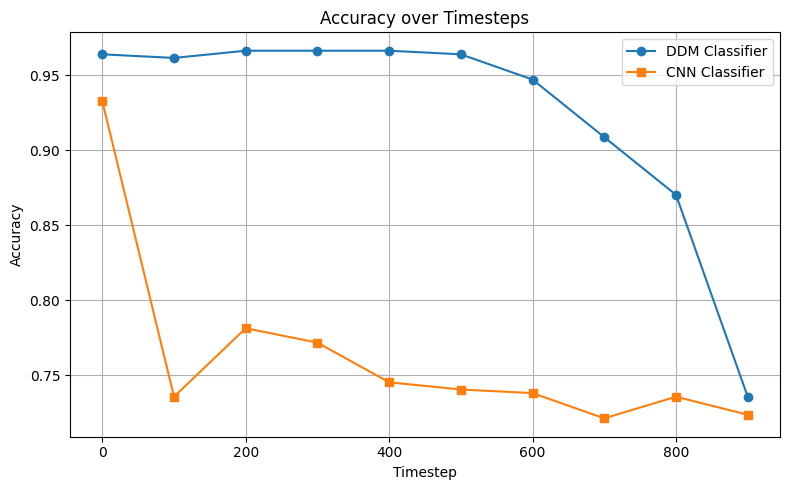

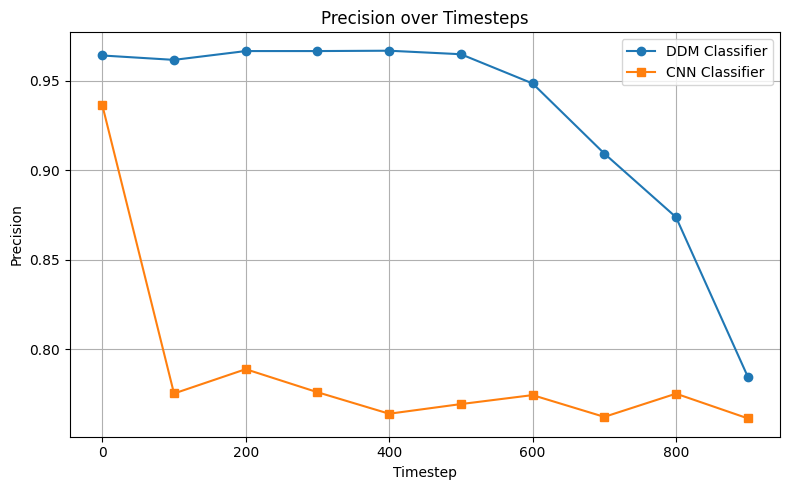

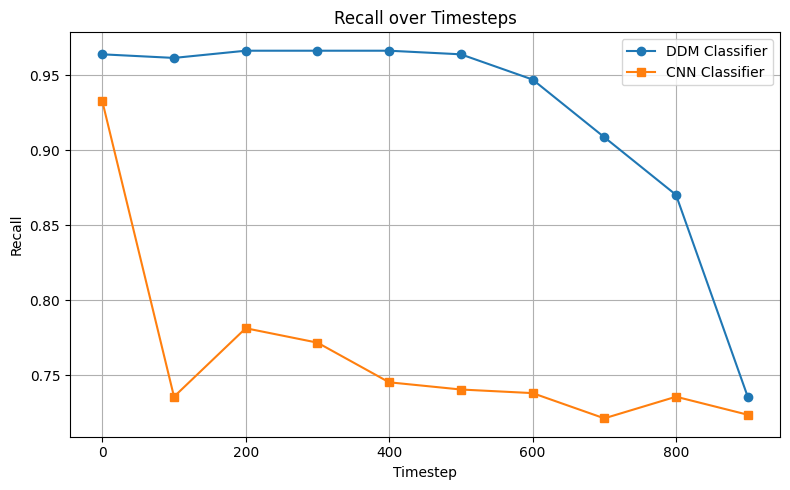

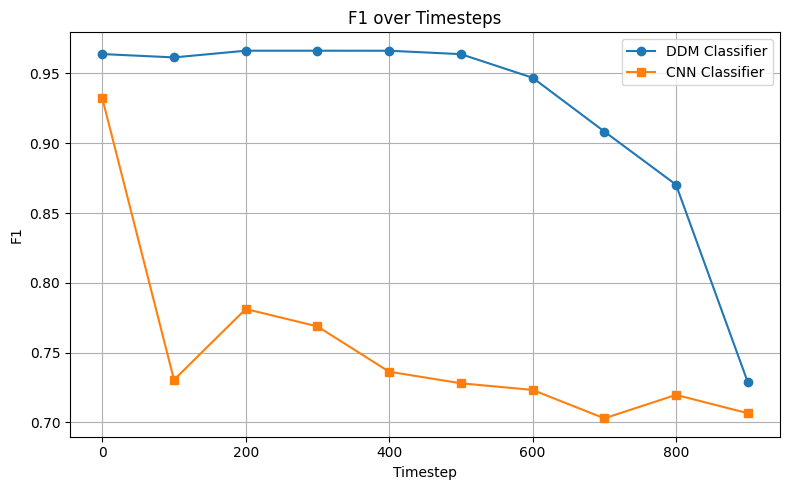

In [99]:
plot_comparison(results_comparison)

The table clearly shows that the DDM classifier is significantly more robust to noise compared to the CNN Classifier baseline. At timestep 0, when no noise is present, both models perform well: DDM achieves an F1 score of 0.9639, while the CNN Classifier slightly lags behind at 0.9323. As the noise level increases, the DDM maintains strong performance—at timestep 300, it still reaches an F1 of 0.9663, whereas the CNN Classifier drops to 0.7837. By timestep 900, the performance of both models declines, which is expected due to high noise; however, the DDM remains competitive with an F1 of 0.6525, while the CNN Classifier achieves 0.6964 but shows less stability across timesteps.

These results provide clear evidence that the DDM classifier, trained to account for noise explicitly, is more resilient and stable in noisy scenarios compared to a standard CNN Classifier.



=== Timestep: 0 ===


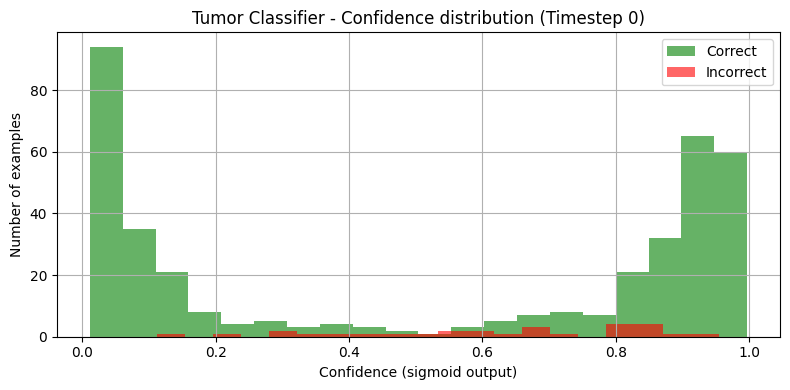


=== Timestep: 111 ===


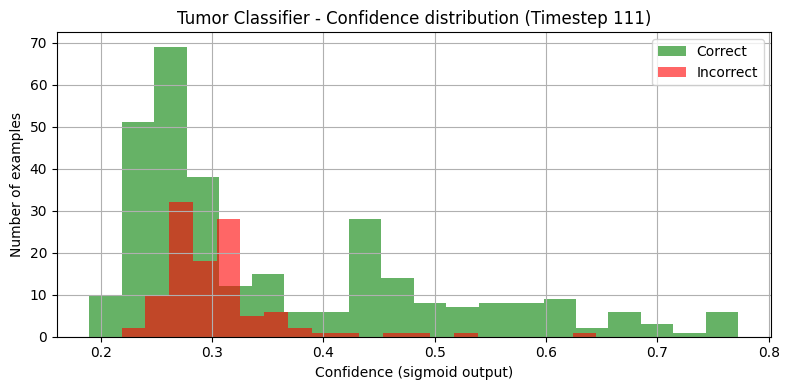


=== Timestep: 222 ===


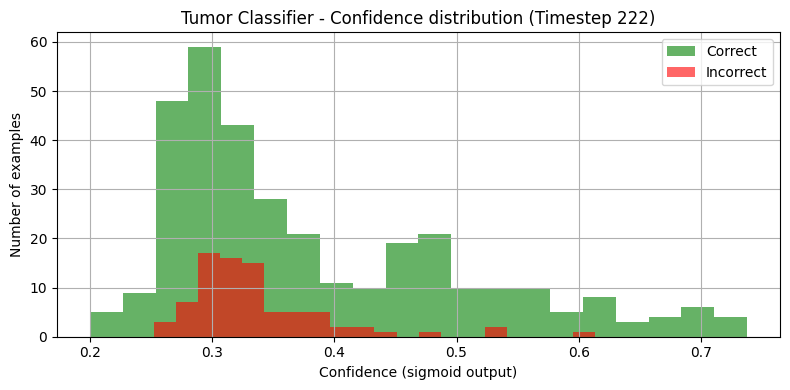


=== Timestep: 333 ===


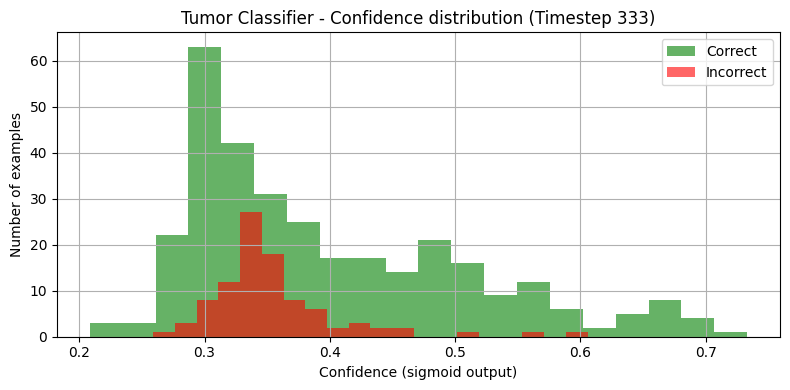


=== Timestep: 444 ===


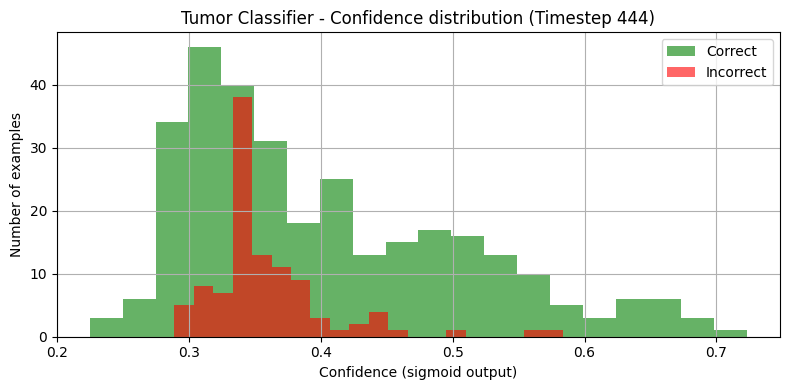


=== Timestep: 555 ===


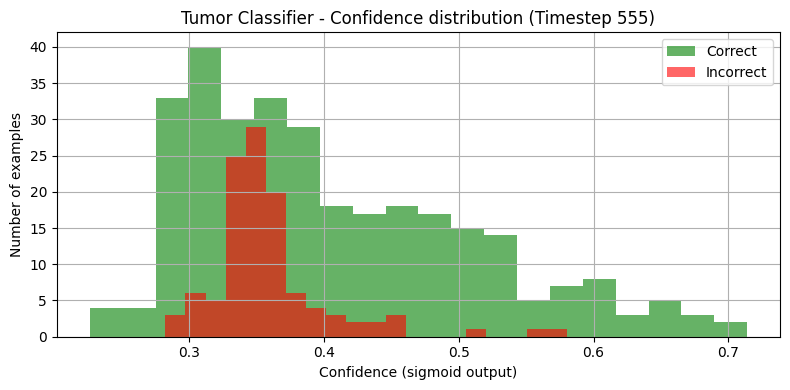


=== Timestep: 666 ===


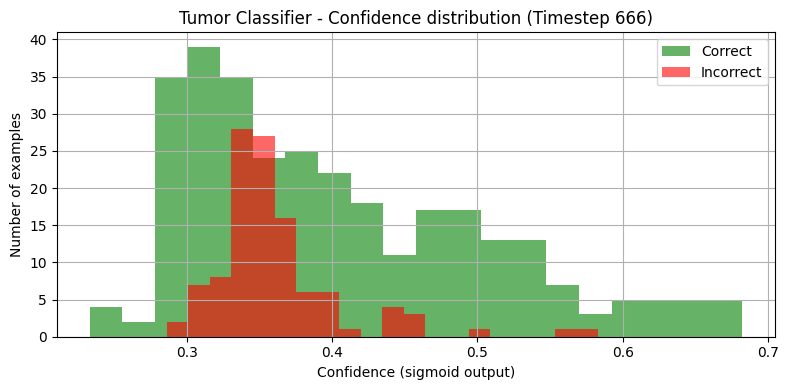


=== Timestep: 777 ===


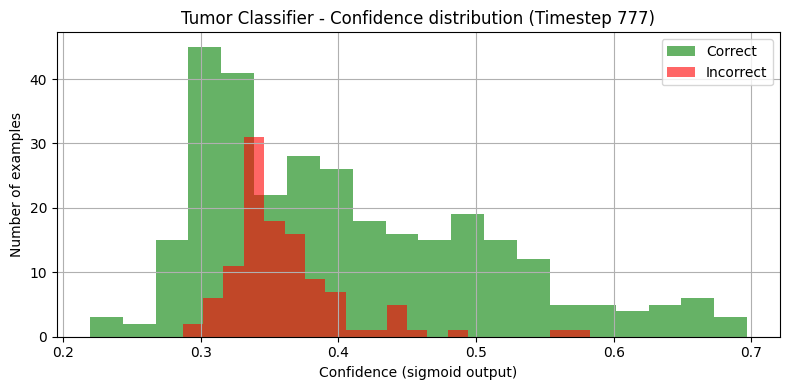


=== Timestep: 888 ===


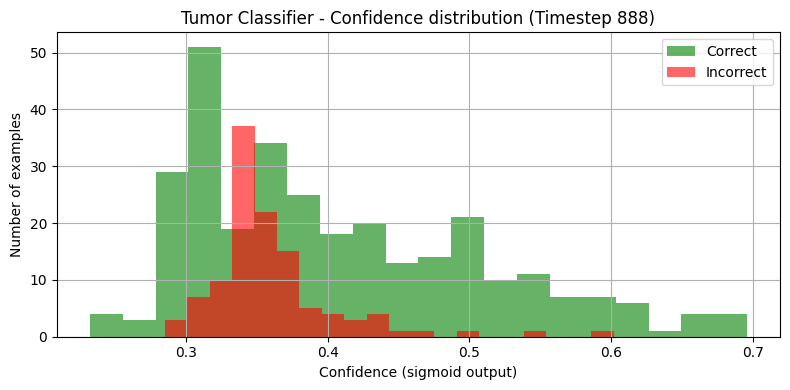


=== Timestep: 999 ===


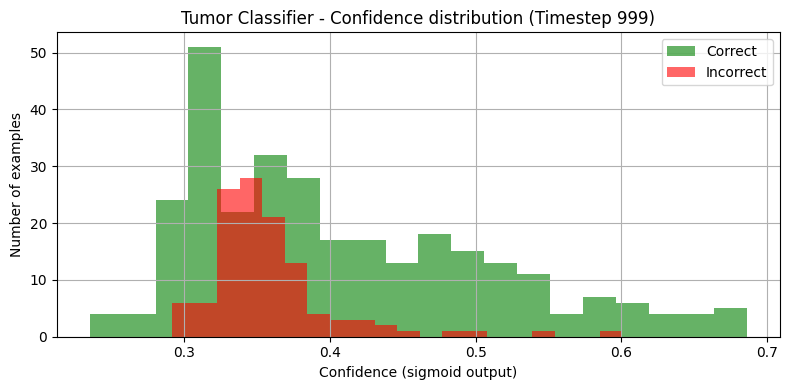

In [101]:
for timestep in timesteps_to_test:
    print(f"\n=== Timestep: {timestep} ===")

    all_probs_cnn_noisy = []
    all_preds_cnn_noisy = []
    all_labels_cnn_noisy = []

    alpha_bar = alphas_cumprod[timestep].item()
    noise_std = (1 - alpha_bar) ** 0.5

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            if timestep == 0:
                images_noisy = images  # No noise
            else:
                noise_img = torch.randn_like(images) * noise_std
                images_noisy = torch.clamp(images + noise_img, 0.0, 1.0)

            logits_cnn = classifier_model(images_noisy)
            probs = torch.sigmoid(logits_cnn).squeeze(1)
            preds = (probs > 0.33).long()

            all_probs_cnn_noisy.extend(probs.cpu().numpy())
            all_preds_cnn_noisy.extend(preds.cpu().numpy())
            all_labels_cnn_noisy.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_preds_cnn_noisy = np.array(all_preds_cnn_noisy).astype(int)
    all_labels_cnn_noisy = np.array(all_labels_cnn_noisy).astype(int)
    all_probs_cnn_noisy = np.array(all_probs_cnn_noisy)

    correct = all_preds_cnn_noisy == all_labels_cnn_noisy
    incorrect = ~correct

    # Plot confidence histogram
    plt.figure(figsize=(8, 4))
    plt.hist(all_probs_cnn_noisy[correct], bins=20, alpha=0.6, label="Correct", color='green')
    plt.hist(all_probs_cnn_noisy[incorrect], bins=20, alpha=0.6, label="Incorrect", color='red')
    plt.xlabel("Confidence (sigmoid output)")
    plt.ylabel("Number of examples")
    plt.title(f"Tumor Classifier - Confidence distribution (Timestep {timestep})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


The confidence plots clearly show the effect of noise on the encoder+Classifier outputs. At timestep zero, the confidence distribution closely resembles what was previously observed in the model’s conformal predictions, with a clear separation between correct predictions (green) and incorrect ones (red).

As noise increases (t > 0), the distribution quickly stabilizes into a pattern featuring multiple peaks of both green and red, clustered around the model’s classification threshold of 0.33. The red peaks, representing misclassified examples, tend to increase slightly as the timestep advances, but without drastic changes. This suggests that despite the added noise, the model maintains a certain robustness in its confidence levels, although the distinction between correct and incorrect predictions becomes less pronounced compared to the noise-free case.


# Encoder + Denoiser + ResNet

### Architecture design and training

This pipeline aims to classify images by first encoding them into a latent space, then simulating and denoising noise at different diffusion timesteps. The cleaned latent representation is finally classified by a ResNet, improving robustness to noisy inputs.


In [ ]:
latent_dim = 128 

resnet = nn.Sequential(
    ResNetBlock1D(in_features=latent_dim, out_features=256, dropout_rate=0.2), 
    ResNetBlock1D(in_features=256, out_features=128, dropout_rate=0.2),
    ResNetBlock1D(in_features=128, out_features=64, dropout_rate=0.2),
    nn.Linear(64, 1)  # output layer for binary classification
)

denoise_res_model = DenoiserResNetClassifier(
    encoder=model.encoder,
    denoiser=train_denoiser_model,
    resnet_1d=resnet,
    latent_dim=128,
    T=1000,
    alphas_cumprod=alphas_cumprod
)

optimizer_ddm = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, denoise_res_model.parameters()),
    lr=1e-4,
    weight_decay=1e-3  
)


In [17]:
trained_denoise_res_model = train_ddm_resnet_classifier(
    ddm_classifier_model=denoise_res_model,
    optimizer_ddm=optimizer_ddm,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    epochs=50  
)

Starting training without uncertainty modeling...


Epoch 1/50 [Val]: 100%|██████████| 10/10 [00:15<00:00,  1.56s/it, loss=0.564]


Epoch 1/50 | Train Loss: 0.6400 | Val Loss: 0.5214 | Val Acc: 0.7616 | Val Prec: 0.9083 | Val Rec: 0.6412 | Val F1: 0.7517
--> Saved best model with Val Loss: 0.5214


Epoch 2/50 [Val]: 100%|██████████| 10/10 [00:08<00:00,  1.19it/s, loss=0.392]


Epoch 2/50 | Train Loss: 0.4476 | Val Loss: 0.3954 | Val Acc: 0.8493 | Val Prec: 0.9136 | Val Rec: 0.8088 | Val F1: 0.8580
--> Saved best model with Val Loss: 0.3954


...

Epoch 25/50 | Train Loss: 0.0807 | Val Loss: 0.1502 | Val Acc: 0.9404 | Val Prec: 0.9343 | Val Rec: 0.9618 | Val F1: 0.9478
Epochs with no improvement: 3/5


Epoch 26/50 [Val]: 100%|██████████| 10/10 [00:07<00:00,  1.28it/s, loss=0.0631]


Epoch 26/50 | Train Loss: 0.0977 | Val Loss: 0.1199 | Val Acc: 0.9553 | Val Prec: 0.9589 | Val Rec: 0.9618 | Val F1: 0.9604
Epochs with no improvement: 4/5


Epoch 27/50 [Val]: 100%|██████████| 10/10 [00:07<00:00,  1.33it/s, loss=0.127]

Epoch 27/50 | Train Loss: 0.0892 | Val Loss: 0.1245 | Val Acc: 0.9487 | Val Prec: 0.9531 | Val Rec: 0.9559 | Val F1: 0.9545
Epochs with no improvement: 5/5
Early stopping triggered at epoch 27

Training complete.


Again threshold method:

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

trained_denoise_res_model.eval()
all_probs_ddm_res = []
all_labels_ddm_res = []
T = 1000  

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        t = torch.randint(0, int(T), (images.size(0),), device=device)

        # Directly call the model that handles everything internally
        logits = trained_denoise_res_model(images, t)
        probs = torch.sigmoid(logits)

        all_probs_ddm_res.extend(probs.cpu().numpy())
        all_labels_ddm_res.extend(labels.cpu().numpy())

# Compute metrics for various thresholds
all_probs_ddm_res = np.array(all_probs_ddm_res).flatten()
all_labels_ddm_res = np.array(all_labels_ddm_res).flatten()

for threshold in np.arange(0.1, 1.0, 0.01):
    preds = (all_probs_ddm_res > threshold).astype(int)
    acc = accuracy_score(all_labels_ddm_res, preds)
    prec = precision_score(all_labels_ddm_res, preds, zero_division=0)
    rec = recall_score(all_labels_ddm_res, preds, zero_division=0)
    f1 = f1_score(all_labels_ddm_res, preds, zero_division=0)
    print(f"Threshold: {threshold:.2f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")


Threshold: 0.10 | Acc: 0.9255 | Prec: 0.8902 | Rec: 0.9821 | F1: 0.9339
Threshold: 0.11 | Acc: 0.9255 | Prec: 0.8902 | Rec: 0.9821 | F1: 0.9339
Threshold: 0.12 | Acc: 0.9255 | Prec: 0.8902 | Rec: 0.9821 | F1: 0.9339
Threshold: 0.13 | Acc: 0.9255 | Prec: 0.8934 | Rec: 0.9776 | F1: 0.9336
Threshold: 0.14 | Acc: 0.9279 | Prec: 0.8971 | Rec: 0.9776 | F1: 0.9356
Threshold: 0.15 | Acc: 0.9279 | Prec: 0.8971 | Rec: 0.9776 | F1: 0.9356
Threshold: 0.16 | Acc: 0.9303 | Prec: 0.9008 | Rec: 0.9776 | F1: 0.9376
Threshold: 0.17 | Acc: 0.9303 | Prec: 0.9076 | Rec: 0.9686 | F1: 0.9371
Threshold: 0.18 | Acc: 0.9303 | Prec: 0.9076 | Rec: 0.9686 | F1: 0.9371
Threshold: 0.19 | Acc: 0.9279 | Prec: 0.9072 | Rec: 0.9641 | F1: 0.9348
Threshold: 0.20 | Acc: 0.9279 | Prec: 0.9072 | Rec: 0.9641 | F1: 0.9348
Threshold: 0.21 | Acc: 0.9279 | Prec: 0.9072 | Rec: 0.9641 | F1: 0.9348
Threshold: 0.22 | Acc: 0.9279 | Prec: 0.9072 | Rec: 0.9641 | F1: 0.9348
Threshold: 0.23 | Acc: 0.9279 | Prec: 0.9072 | Rec: 0.9641 | F1:

The best threshold was identified at 0.22, with those metrics:

Acc: 0.9279 | Prec: 0.9072 | Rec: 0.9641 | F1: 0.9348


TP: 215, TN: 170, FP: 23, FN: 8
Accuracy: 0.9255
Precision: 0.9034
Recall: 0.9641
F1-score: 0.9328


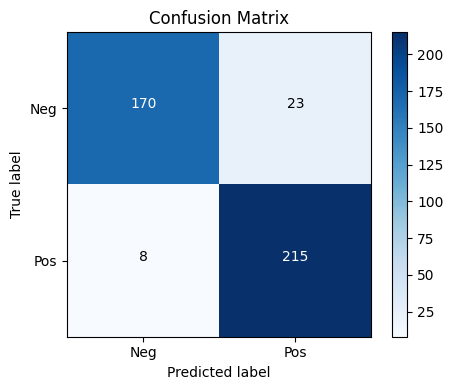

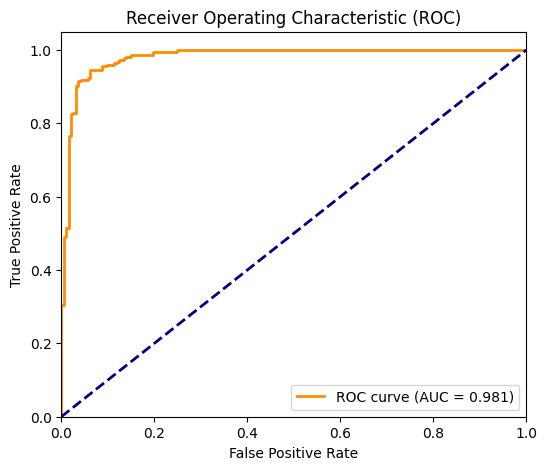

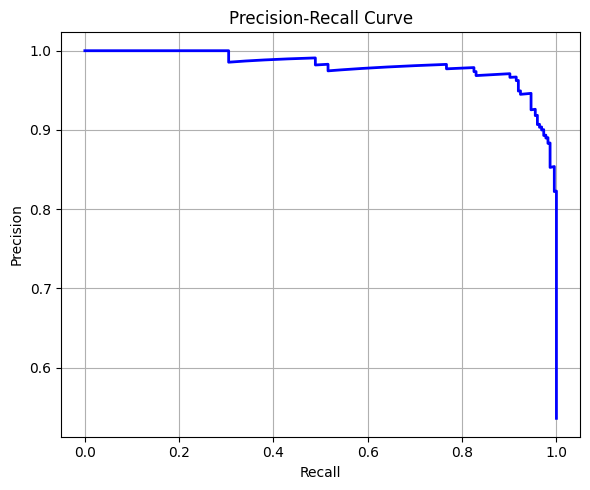

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score

trained_denoise_res_model.eval()
all_preds_ddm_res = []
all_probs_ddm_res = []
all_labels_ddm_res = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        # timestep for each batch
        t = torch.randint(0, int(T), (images.size(0),), device=device)


        # Forward pass through the model (encoder, denoiser, classifier handled internally)
        logits = trained_denoise_res_model(images, t)
        probs = torch.sigmoid(logits)  # Output probabilities

        preds = (probs > 0.22).int()  # Custom threshold

        all_probs_ddm_res.extend(probs.cpu().numpy())
        all_preds_ddm_res.extend(preds.cpu().numpy())
        all_labels_ddm_res.extend(labels.cpu().numpy())

# Convert to 1D numpy arrays
all_preds_ddm_res = np.array(all_preds_ddm_res).flatten().astype(int)
all_labels_ddm_res = np.array(all_labels_ddm_res).flatten().astype(int)
all_probs_ddm_res = np.array(all_probs_ddm_res).flatten()

# === Basic Metrics ===
TP = ((all_preds_ddm_res == 1) & (all_labels_ddm_res == 1)).sum()
TN = ((all_preds_ddm_res == 0) & (all_labels_ddm_res == 0)).sum()
FP = ((all_preds_ddm_res == 1) & (all_labels_ddm_res == 0)).sum()
FN = ((all_preds_ddm_res == 0) & (all_labels_ddm_res == 1)).sum()

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

acc = (TP + TN) / (TP + TN + FP + FN + 1e-8)
prec = TP / (TP + FP + 1e-8)
rec = TP / (TP + FN + 1e-8)
f1 = 2 * prec * rec / (prec + rec + 1e-8)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# === Confusion Matrix ===
cm = confusion_matrix(all_labels_ddm_res, all_preds_ddm_res)
plt.figure(figsize=(5, 4))
plt.title("Confusion Matrix")
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Neg', 'Pos'])
plt.yticks(tick_marks, ['Neg', 'Pos'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# === ROC Curve ===
fpr, tpr, _ = roc_curve(all_labels_ddm_res, all_probs_ddm_res)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# === Precision-Recall Curve ===
precision, recall, _ = precision_recall_curve(all_labels_ddm_res, all_probs_ddm_res)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.tight_layout()
plt.show()


In [45]:
torch.save(trained_denoise_res_model.state_dict(), "Den_ReSN.pth")

In [ ]:
trained_denoise_res_model =  DenoiserResNetClassifier(
    encoder=model.encoder,
    denoiser=train_denoiser_model,
    resnet_1d=resnet,
    latent_dim=128,
    T=1000,
    alphas_cumprod=alphas_cumprod
)
trained_denoise_res_model.load_state_dict(torch.load("Models/Den_ReSN.pth"))
trained_denoise_res_model.eval()  

DenoiserResNetClassifier(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (denoiser): LatentDenoiserResidual(
    (time_embed): SinusoidalTimeEmbedding()
    (input_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (input_linear): Linear(in_features=256, out_features=512, bias=True)
    (res1): ResidualBlock(
      (block): Sequential(
        (0): La

## Conformal prediction


Significance Level (alpha): 0.1
Desired Coverage: 0.9
Number of calibration scores: 339
Quantile index: 305
Calculated q_hat (threshold): 0.1977

Conformal Prediction Results:
Total samples in final test set: 416
Empirical Coverage: 0.9062 (Expected: >= 0.9)
Average Prediction Set Size: 0.9399


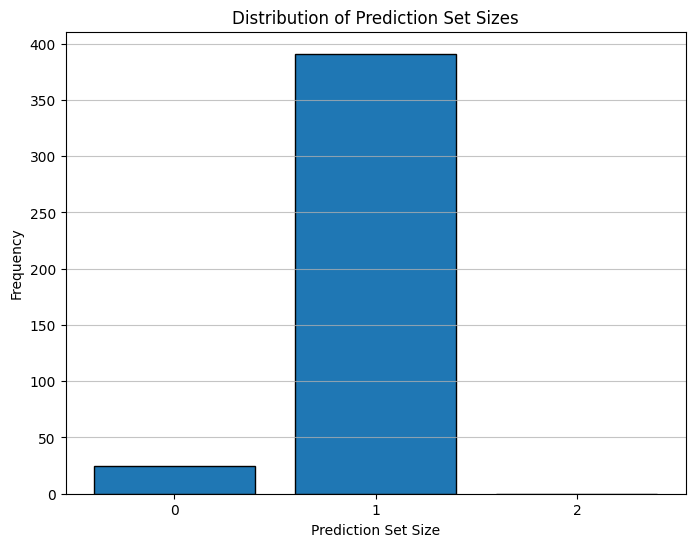

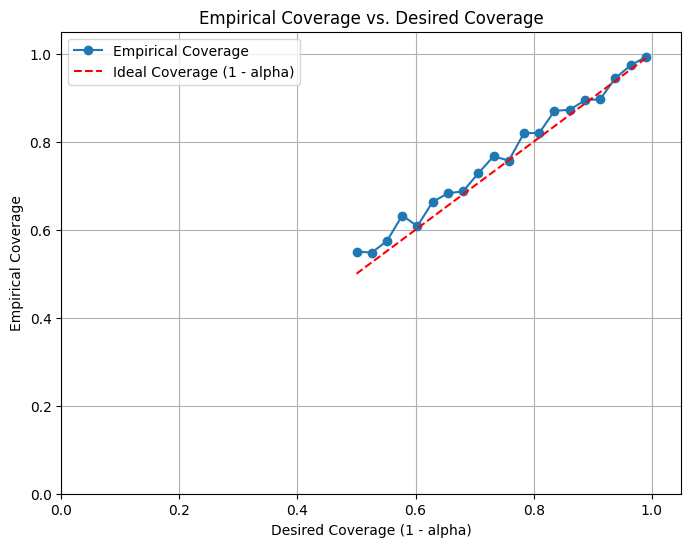

In [29]:
conformal_prediction(
    model=trained_denoise_res_model,
    alpha=0.1,
    calibration_loader=calibration_loader,
    test_loader=test_loader,
    device=device)

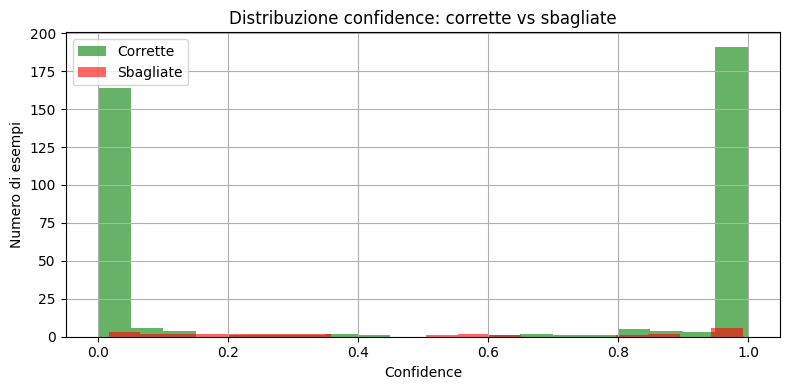

In [35]:
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()
all_probs = np.array(all_probs).flatten() 

correct = all_preds == all_labels
incorrect = ~correct

plt.figure(figsize=(8, 4))
plt.hist(all_probs[correct], bins=20, alpha=0.6, label="Corrette", color='green')
plt.hist(all_probs[incorrect], bins=20, alpha=0.6, label="Sbagliate", color='red')
plt.xlabel("Confidence")
plt.ylabel("Numero di esempi")
plt.title("Distribuzione confidence: corrette vs sbagliate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




The conformal prediction procedure was conducted with a significance level (alpha) of 0.1, aiming for a coverage of at least 90%. Using 339 calibration scores, the quantile index was determined to be 305, leading to a threshold (q_hat) of approximately 0.1977.

On the final test set of 416 samples, the empirical coverage achieved was 90.62%, slightly exceeding the target coverage of 90%, indicating that the prediction sets are well-calibrated. Additionally, the average prediction set size is 0.9399, which suggests relatively small and informative prediction sets, balancing coverage and precision effectively.

Notably, the model appears highly confident, as reflected by the relatively low q_hat value. This suggests that the denoising process might already bias the model towards a particular class. Indeed, the confidence distribution plot shows a slight density of low-confidence scores (between 0 and 0.3), indicating that, despite its general confidence, the model primarily makes errors in a specific direction. This behavior hints at systematic biases possibly introduced during the denoising stage.
